# Project Setup

In [1]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 50)

# Show all files added in Kaggle input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


def find_file(filename):
    matches = []
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for f in filenames:
            if f == filename:
                matches.append(os.path.join(dirname, f))
                
    if len(matches) == 0:
        raise FileNotFoundError(f"{filename} not found. Check Kaggle input file name.")
    
    print(f"{filename} loaded from: {matches[0]}")
    return matches[0]

/kaggle/input/private-dataset/former_names.csv
/kaggle/input/private-dataset/goalscorers.csv
/kaggle/input/private-dataset/shootouts.csv
/kaggle/input/private-dataset/results.csv
/kaggle/input/datasets/lucasyukioimafuko/fifa-mens-world-ranking/fifa_mens_rank.csv
/kaggle/input/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/female_coaches.csv
/kaggle/input/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/male_teams.csv
/kaggle/input/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/female_players.csv
/kaggle/input/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/male_players.csv
/kaggle/input/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/female_teams.csv
/kaggle/input/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/male_coaches.csv


1.1 Libraries and Environment Setup

1.2 Dataset Overview and Loading

In [2]:
players_path = find_file('male_players.csv')
ranking_path = find_file('fifa_mens_rank.csv')
results_path = find_file('results.csv')
goalscorers_path = find_file('goalscorers.csv')
shootouts_path = find_file('shootouts.csv')
former_names_path = find_file('former_names.csv')

players_raw = pd.read_csv(players_path, low_memory=False)
ranking_raw = pd.read_csv(ranking_path, low_memory=False)
results_raw = pd.read_csv(results_path, low_memory=False)
goalscorers_raw = pd.read_csv(goalscorers_path, low_memory=False)
shootouts_raw = pd.read_csv(shootouts_path, low_memory=False)
former_names_raw = pd.read_csv(former_names_path, low_memory=False)

print("Players:", players_raw.shape)
print("Ranking:", ranking_raw.shape)
print("Results:", results_raw.shape)
print("Goalscorers:", goalscorers_raw.shape)
print("Shootouts:", shootouts_raw.shape)
print("Former names:", former_names_raw.shape)

male_players.csv loaded from: /kaggle/input/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/male_players.csv
fifa_mens_rank.csv loaded from: /kaggle/input/datasets/lucasyukioimafuko/fifa-mens-world-ranking/fifa_mens_rank.csv
results.csv loaded from: /kaggle/input/private-dataset/results.csv
goalscorers.csv loaded from: /kaggle/input/private-dataset/goalscorers.csv
shootouts.csv loaded from: /kaggle/input/private-dataset/shootouts.csv
former_names.csv loaded from: /kaggle/input/private-dataset/former_names.csv
Players: (180021, 109)
Ranking: (13130, 8)
Results: (49520, 9)
Goalscorers: (47903, 8)
Shootouts: (683, 5)
Former names: (36, 4)


# Data Cleaning and Preparation

**2.1 Initial Data Quality Audit Before Cleaning**

In [3]:
# =========================================================
# INITIAL DATA QUALITY AUDIT BEFORE CLEANING
# =========================================================

raw_datasets = {
    'EA FC Player Data': players_raw,
    'FIFA Ranking Data': ranking_raw,
    'International Results': results_raw,
    'Goalscorers Data': goalscorers_raw,
    'Shootouts Data': shootouts_raw,
    'Former Names Data': former_names_raw
}

initial_quality_rows = []

for dataset_name, df in raw_datasets.items():

    rows = len(df)
    columns = len(df.columns)

    duplicate_rows = df.duplicated().sum()

    missing_cells = df.isnull().sum().sum()

    total_cells = rows * columns

    missing_percentage = (
        (missing_cells / total_cells) * 100
        if total_cells > 0 else 0
    )

    initial_quality_rows.append([
        dataset_name,
        rows,
        columns,
        duplicate_rows,
        missing_cells,
        missing_percentage
    ])


initial_quality_df = pd.DataFrame(
    initial_quality_rows,
    columns=[
        'Dataset',
        'Rows',
        'Columns',
        'Duplicate Rows',
        'Missing Cells',
        'Missing (%)'
    ]
)


print("=" * 75)
print("INITIAL DATA QUALITY AUDIT")
print("=" * 75)

display(
    initial_quality_df.round(2)
)

INITIAL DATA QUALITY AUDIT


,Dataset,Rows,Columns,Duplicate Rows,Missing Cells,Missing (%)
0,EA FC Player Data,180021,109,0,1347608,6.87
1,FIFA Ranking Data,13130,8,2,0,0.00
2,International Results,49520,9,0,4,0.00
3,Goalscorers Data,47903,8,79,298,0.08
4,Shootouts Data,683,5,0,423,12.39
5,Former Names Data,36,4,0,0,0.00


**2.2 Country Name Standardisation**

In [4]:
def clean_country_name(name):
    if pd.isna(name):
        return np.nan
    
    name = str(name).strip()
    
    country_map = {
        'Cape Verde Islands': 'Cape Verde',
        'Cabo Verde': 'Cape Verde',
        'Korea Republic': 'South Korea',
        'Korea DPR': 'North Korea',
        'USA': 'United States',
        'United States of America': 'United States',
        'IR Iran': 'Iran',
        'Türkiye': 'Turkey',
        'Czech Republic': 'Czechia',
        'Ivory Coast': 'Côte d’Ivoire',
        'Côte dIvoire': 'Côte d’Ivoire',
        'Cote dIvoire': 'Côte d’Ivoire',
        'England': 'England',
        'Scotland': 'Scotland',
        'Wales': 'Wales',
        'Northern Ireland': 'Northern Ireland'
    }
    
    return country_map.get(name, name)

**2.3 Player Dataset Preparation**

2.3.1 Latest FC Version and Relevant Feature Selection

In [5]:

# STEP 1: PLAYER DATASET SELECTION AND FEATURE PREPARATION


players = players_raw.copy()

print("=" * 70)
print("STEP 1: INITIAL PLAYER DATA")
print("=" * 70)

print("Original player dataset shape:", players.shape)



# 1. Clean column names


players.columns = players.columns.str.strip()


# ---------------------------------------------------------
# 2. Keep latest FIFA / EA FC version
# ---------------------------------------------------------

rows_before_version_filter = len(players)

if 'fifa_version' in players.columns:

    latest_version = players['fifa_version'].max()

    players = players[
        players['fifa_version'] == latest_version
    ].copy()

    print("\nLatest FIFA/FC version selected:", latest_version)

else:

    latest_version = "Not available"


rows_after_version_filter = len(players)

print(
    "Rows before version filtering:",
    rows_before_version_filter
)

print(
    "Rows after version filtering:",
    rows_after_version_filter
)

print(
    "Older-version rows removed:",
    rows_before_version_filter
    - rows_after_version_filter
)


# ---------------------------------------------------------
# 3. Select relevant player features
# ---------------------------------------------------------

needed_player_columns = [

    'player_id',
    'short_name',
    'long_name',
    'age',
    'height_cm',
    'club_name',
    'league_name',
    'weight_kg',

    'nationality_name',
    'player_positions',

    'overall',
    'potential',

    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic',

    'attacking_crossing',
    'attacking_finishing',
    'attacking_heading_accuracy',
    'attacking_short_passing',
    'attacking_volleys',

    'skill_dribbling',
    'skill_curve',
    'skill_long_passing',
    'skill_ball_control',

    'movement_acceleration',
    'movement_sprint_speed',
    'movement_agility',
    'movement_reactions',
    'movement_balance',

    'power_shot_power',
    'power_jumping',
    'power_stamina',
    'power_strength',
    'power_long_shots',

    'mentality_aggression',
    'mentality_interceptions',
    'mentality_positioning',
    'mentality_vision',
    'mentality_composure',

    'defending_marking_awareness',
    'defending_standing_tackle',
    'defending_sliding_tackle',

    'goalkeeping_diving',
    'goalkeeping_handling',
    'goalkeeping_kicking',
    'goalkeeping_positioning',
    'goalkeeping_reflexes'
]


columns_before_selection = len(players.columns)

existing_player_columns = [
    col
    for col in needed_player_columns
    if col in players.columns
]

players = players[
    existing_player_columns
].copy()


print("\nColumns before feature selection:", columns_before_selection)

print(
    "Relevant columns retained:",
    len(existing_player_columns)
)

print(
    "Unnecessary columns removed:",
    columns_before_selection
    - len(existing_player_columns)
)

print("\nPrepared player dataset shape:", players.shape)

display(
    players.head()
)

STEP 1: INITIAL PLAYER DATA
Original player dataset shape: (180021, 109)

Latest FIFA/FC version selected: 24.0
Rows before version filtering: 180021
Rows after version filtering: 18350
Older-version rows removed: 161671

Columns before feature selection: 109
Relevant columns retained: 50
Unnecessary columns removed: 59

Prepared player dataset shape: (18350, 50)


,player_id,short_name,long_name,age,height_cm,club_name,league_name,weight_kg,nationality_name,player_positions,overall,potential,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,231747,K. Mbappé,Kylian Mbappé Lottin,24,182,Paris Saint Germain,Ligue 1,75,France,"ST, LW",91,94,97.0,90.0,80.0,92.0,36.0,78.0,78,94,73,86,84,93,80,71,92,97,97,93,93,82,90,88,88,77,83,64,38,93,83,88.0,26,34,32,13,5,7,11,6
1,239085,E. Haaland,Erling Braut Haaland,22,195,Manchester City,Premier League,94,Norway,ST,91,94,89.0,93.0,66.0,80.0,45.0,88.0,47,96,83,77,90,79,77,53,82,82,94,76,94,72,94,93,76,93,86,87,43,96,74,87.0,38,47,29,7,14,13,11,7
2,192985,K. De Bruyne,Kevin De Bruyne,32,181,Manchester City,Premier League,75,Belgium,"CM, CAM",91,91,72.0,88.0,94.0,87.0,65.0,78.0,95,85,55,94,83,86,92,94,92,72,72,74,92,78,92,72,88,74,92,75,66,88,95,88.0,66,70,53,15,13,5,10,13
3,158023,L. Messi,Lionel Andrés Messi Cuccittini,36,169,Inter Miami,Major League Soccer,67,Argentina,"CF, CAM",90,90,80.0,87.0,90.0,94.0,33.0,64.0,83,89,60,91,86,96,93,90,93,87,74,91,88,95,83,71,70,68,90,44,40,91,92,96.0,20,35,24,6,11,15,14,8
4,165153,K. Benzema,Karim Benzema,35,185,Al Ittihad,Pro League,81,France,"CF, ST",90,90,79.0,88.0,83.0,87.0,39.0,78.0,75,91,90,89,88,87,82,76,91,78,79,77,92,72,87,85,82,82,81,63,39,92,90,90.0,43,24,18,13,11,5,5,7


2.3.2 Duplicate Detection and Handling

In [6]:

# STEP 2: DUPLICATE DETECTION AND HANDLING


print("=" * 70)
print("STEP 2: DUPLICATE PLAYER HANDLING")
print("=" * 70)


rows_before_duplicate_removal = len(players)


# ---------------------------------------------------------
# Detect duplicates
# ---------------------------------------------------------

if 'player_id' in players.columns:

    duplicate_player_count = players.duplicated(
        subset=['player_id']
    ).sum()

    print(
        "Duplicate Player IDs before cleaning:",
        duplicate_player_count
    )

    players = players.drop_duplicates(
        subset=['player_id'],
        keep='first'
    ).copy()


else:

    duplicate_player_count = players.duplicated(
        subset=[
            'short_name',
            'nationality_name',
            'player_positions'
        ]
    ).sum()

    print(
        "Duplicate player records before cleaning:",
        duplicate_player_count
    )

    players = players.drop_duplicates(
        subset=[
            'short_name',
            'nationality_name',
            'player_positions'
        ],
        keep='first'
    ).copy()


rows_after_duplicate_removal = len(players)


print(
    "Rows before duplicate removal:",
    rows_before_duplicate_removal
)

print(
    "Rows after duplicate removal:",
    rows_after_duplicate_removal
)

print(
    "Duplicate rows removed:",
    rows_before_duplicate_removal
    - rows_after_duplicate_removal
)


if 'player_id' in players.columns:

    print(
        "Duplicate Player IDs after cleaning:",
        players.duplicated(
            subset=['player_id']
        ).sum()
    )

STEP 2: DUPLICATE PLAYER HANDLING
Duplicate Player IDs before cleaning: 0
Rows before duplicate removal: 18350
Rows after duplicate removal: 18350
Duplicate rows removed: 0
Duplicate Player IDs after cleaning: 0


2.3.3 Critical Missing-Value Removal and Position Classification

In [7]:
# =========================================================
# STEP 3: CRITICAL MISSING VALUES AND POSITION GROUPING
# =========================================================

print("=" * 70)
print("STEP 3: CRITICAL MISSING VALUES AND POSITION GROUPING")
print("=" * 70)


# ---------------------------------------------------------
# 1. Check critical missing values
# ---------------------------------------------------------

critical_columns = [
    'short_name',
    'nationality_name',
    'player_positions',
    'overall'
]


critical_missing_before = (
    players[critical_columns]
    .isnull()
    .sum()
)


print("\nCritical missing values BEFORE removal:")

display(
    critical_missing_before
    .rename('Missing Values')
    .to_frame()
)


rows_before_critical_drop = len(players)


# ---------------------------------------------------------
# 2. Remove unusable records
# ---------------------------------------------------------

players = players.dropna(
    subset=critical_columns
).copy()


rows_after_critical_drop = len(players)


print(
    "\nRows removed because of critical missing data:",
    rows_before_critical_drop
    - rows_after_critical_drop
)


# ---------------------------------------------------------
# 3. Position functions
# ---------------------------------------------------------

def get_primary_position(position_text):

    if pd.isna(position_text):
        return np.nan

    return str(
        position_text
    ).split(',')[0].strip()


def get_position_group(position_text):

    primary_pos = get_primary_position(
        position_text
    )

    if pd.isna(primary_pos):
        return 'Other'

    if primary_pos == 'GK':

        return 'Goalkeeper'

    elif primary_pos in [
        'CB', 'LB', 'RB', 'LWB', 'RWB'
    ]:

        return 'Defender'

    elif primary_pos in [
        'CM', 'CDM', 'CAM', 'LM', 'RM'
    ]:

        return 'Midfielder'

    elif primary_pos in [
        'ST', 'CF', 'LW', 'RW'
    ]:

        return 'Attacker'

    else:

        return 'Other'


# ---------------------------------------------------------
# 4. Create standardised fields
# ---------------------------------------------------------

players['primary_position'] = (
    players['player_positions']
    .apply(get_primary_position)
)

players['position_group'] = (
    players['player_positions']
    .apply(get_position_group)
)

players['country_std'] = (
    players['nationality_name']
    .apply(clean_country_name)
)


# ---------------------------------------------------------
# 5. Remove unsupported positions
# ---------------------------------------------------------

other_position_count = (
    players['position_group'] == 'Other'
).sum()


print(
    "Unsupported/Other position records:",
    other_position_count
)


players = players[
    players['position_group'] != 'Other'
].copy()


print(
    "Player dataset after position preparation:",
    players.shape
)


print("\nPosition-group distribution:")

display(
    players['position_group']
    .value_counts()
    .rename_axis('Position Group')
    .reset_index(name='Players')
)


display(
    players[
        [
            'short_name',
            'country_std',
            'player_positions',
            'primary_position',
            'position_group',
            'overall'
        ]
    ].head()
)

STEP 3: CRITICAL MISSING VALUES AND POSITION GROUPING

Critical missing values BEFORE removal:


,Missing Values
short_name,0
nationality_name,0
player_positions,0
overall,0



Rows removed because of critical missing data: 0
Unsupported/Other position records: 0
Player dataset after position preparation: (18350, 53)

Position-group distribution:


,Position Group,Players
0,Midfielder,6673
1,Defender,6174
2,Attacker,3458
3,Goalkeeper,2045


,short_name,country_std,player_positions,primary_position,position_group,overall
0,K. Mbappé,France,"ST, LW",ST,Attacker,91
1,E. Haaland,Norway,ST,ST,Attacker,91
2,K. De Bruyne,Belgium,"CM, CAM",CM,Midfielder,91
3,L. Messi,Argentina,"CF, CAM",CF,Attacker,90
4,K. Benzema,France,"CF, ST",CF,Attacker,90


2.3.4 Data-Type Conversion and Missing-Value Imputation

In [8]:
# =========================================================
# STEP 4: DATA TYPES AND MISSING-VALUE IMPUTATION
# =========================================================

print("=" * 70)
print("STEP 4: MISSING-VALUE TREATMENT")
print("=" * 70)


# ---------------------------------------------------------
# 1. Define text columns
# ---------------------------------------------------------

text_cols = [

    'short_name',
    'long_name',
    'nationality_name',
    'country_std',

    'player_positions',
    'primary_position',
    'position_group',

    'club_name',
    'league_name'
]


# ---------------------------------------------------------
# 2. Convert remaining columns to numeric
# ---------------------------------------------------------

numeric_cols = []

for col in players.columns:

    if col not in text_cols:

        players[col] = pd.to_numeric(
            players[col],
            errors='coerce'
        )

        numeric_cols.append(col)


# ---------------------------------------------------------
# 3. Show missing numeric values BEFORE imputation
# ---------------------------------------------------------

missing_before_imputation = (
    players[numeric_cols]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)


print("\nTop missing numeric attributes BEFORE imputation:")

display(
    missing_before_imputation
    .head(15)
    .rename('Missing Before')
    .to_frame()
)


total_numeric_missing_before = (
    players[numeric_cols]
    .isnull()
    .sum()
    .sum()
)


print(
    "Total numeric missing values BEFORE imputation:",
    total_numeric_missing_before
)


# ---------------------------------------------------------
# 4. Position-group median imputation
# ---------------------------------------------------------

for col in numeric_cols:

    group_medians = (
        players
        .groupby('position_group')[col]
        .median()
    )

    players[col] = players[col].fillna(
        players['position_group']
        .map(group_medians)
    )


# ---------------------------------------------------------
# 5. Overall median fallback
# ---------------------------------------------------------

overall_medians = (
    players[numeric_cols]
    .median(numeric_only=True)
)

players[numeric_cols] = (
    players[numeric_cols]
    .fillna(overall_medians)
)


# Final numerical fallback
players[numeric_cols] = (
    players[numeric_cols]
    .fillna(0)
)


# ---------------------------------------------------------
# 6. Optional text fields
# ---------------------------------------------------------

for col in [
    'club_name',
    'league_name'
]:

    if col in players.columns:

        players[col] = (
            players[col]
            .fillna('Unknown')
        )


if 'long_name' in players.columns:

    players['long_name'] = (
        players['long_name']
        .fillna(players['short_name'])
    )


# ---------------------------------------------------------
# 7. Missing values AFTER treatment
# ---------------------------------------------------------

missing_after_imputation = (
    players[numeric_cols]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)


total_numeric_missing_after = (
    players[numeric_cols]
    .isnull()
    .sum()
    .sum()
)


print(
    "\nTotal numeric missing values AFTER imputation:",
    total_numeric_missing_after
)


print(
    "Total missing values in final player dataset:",
    players.isnull().sum().sum()
)


# ---------------------------------------------------------
# 8. Before vs After Missing-Value Table
# ---------------------------------------------------------

missing_comparison = pd.DataFrame({

    'Missing Before':
        missing_before_imputation,

    'Missing After':
        players[numeric_cols]
        .isnull()
        .sum()

})


missing_comparison = (
    missing_comparison
    .sort_values(
        'Missing Before',
        ascending=False
    )
)


print("\nMissing-value comparison:")

display(
    missing_comparison.head(15)
)

STEP 4: MISSING-VALUE TREATMENT

Top missing numeric attributes BEFORE imputation:


,Missing Before
passing,2045
dribbling,2045
pace,2045
shooting,2045
defending,2045
physic,2045
age,0
player_id,0
weight_kg,0
height_cm,0


Total numeric missing values BEFORE imputation: 12270

Total numeric missing values AFTER imputation: 0
Total missing values in final player dataset: 0

Missing-value comparison:


,Missing Before,Missing After
dribbling,2045,0
defending,2045,0
physic,2045,0
shooting,2045,0
pace,2045,0
passing,2045,0
attacking_volleys,0,0
attacking_short_passing,0,0
attacking_heading_accuracy,0,0
attacking_finishing,0,0


2.3.6 Final Player Dataset Quality Validation

In [9]:
# =========================================================
# STEP 5: FINAL PLAYER DATA QUALITY VALIDATION
# =========================================================

print("=" * 70)
print("STEP 5: FINAL PLAYER DATA QUALITY CHECK")
print("=" * 70)


# ---------------------------------------------------------
# Duplicate validation
# ---------------------------------------------------------

if 'player_id' in players.columns:

    remaining_duplicates = (
        players
        .duplicated(
            subset=['player_id']
        )
        .sum()
    )

else:

    remaining_duplicates = (
        players
        .duplicated()
        .sum()
    )


# ---------------------------------------------------------
# Missing-value validation
# ---------------------------------------------------------

remaining_missing = (
    players
    .isnull()
    .sum()
    .sum()
)


# ---------------------------------------------------------
# Attribute range validation
# FIFA/EA football ratings should normally be 0-100
# ---------------------------------------------------------

rating_columns = [

    'overall',
    'potential',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]


rating_columns = [

    col
    for col in rating_columns
    if col in players.columns
]


invalid_rating_values = 0

for col in rating_columns:

    invalid_rating_values += (
        (
            (players[col] < 0)
            |
            (players[col] > 100)
        )
        .sum()
    )


# ---------------------------------------------------------
# Final summary
# ---------------------------------------------------------

print(
    "Final player dataset shape:",
    players.shape
)

print(
    "Remaining duplicate players:",
    remaining_duplicates
)

print(
    "Remaining missing values:",
    remaining_missing
)

print(
    "Invalid 0-100 rating values:",
    invalid_rating_values
)

print(
    "Countries represented:",
    players['country_std'].nunique()
)

print("\nFinal position-group counts:")

display(
    players['position_group']
    .value_counts()
    .rename_axis('Position Group')
    .reset_index(name='Number of Players')
)

STEP 5: FINAL PLAYER DATA QUALITY CHECK
Final player dataset shape: (18350, 53)
Remaining duplicate players: 0
Remaining missing values: 0
Invalid 0-100 rating values: 0
Countries represented: 160

Final position-group counts:


,Position Group,Number of Players
0,Midfielder,6673
1,Defender,6174
2,Attacker,3458
3,Goalkeeper,2045


2.3.7 Position-Specific Player Suitability Score

In [10]:
def safe_value(row, col):
    if col in row.index:
        return row[col]
    return 0


def calculate_suitability(row):
    position = row['position_group']
    
    if position == 'Goalkeeper':
        return (
            0.25 * safe_value(row, 'goalkeeping_diving') +
            0.20 * safe_value(row, 'goalkeeping_reflexes') +
            0.20 * safe_value(row, 'goalkeeping_handling') +
            0.15 * safe_value(row, 'goalkeeping_positioning') +
            0.10 * safe_value(row, 'goalkeeping_kicking') +
            0.10 * safe_value(row, 'overall')
        )
    
    elif position == 'Defender':
        return (
            0.25 * safe_value(row, 'defending') +
            0.20 * safe_value(row, 'defending_standing_tackle') +
            0.15 * safe_value(row, 'mentality_interceptions') +
            0.15 * safe_value(row, 'physic') +
            0.10 * safe_value(row, 'pace') +
            0.10 * safe_value(row, 'attacking_heading_accuracy') +
            0.05 * safe_value(row, 'overall')
        )
    
    elif position == 'Midfielder':
        return (
            0.25 * safe_value(row, 'passing') +
            0.20 * safe_value(row, 'attacking_short_passing') +
            0.15 * safe_value(row, 'mentality_vision') +
            0.15 * safe_value(row, 'skill_dribbling') +
            0.10 * safe_value(row, 'power_stamina') +
            0.10 * safe_value(row, 'defending') +
            0.05 * safe_value(row, 'overall')
        )
    
    elif position == 'Attacker':
        return (
            0.25 * safe_value(row, 'attacking_finishing') +
            0.20 * safe_value(row, 'shooting') +
            0.15 * safe_value(row, 'mentality_positioning') +
            0.15 * safe_value(row, 'pace') +
            0.10 * safe_value(row, 'skill_dribbling') +
            0.10 * safe_value(row, 'power_shot_power') +
            0.05 * safe_value(row, 'overall')
        )
    
    else:
        return 0


players['suitability_score'] = players.apply(calculate_suitability, axis=1)

players[['short_name', 'country_std', 'primary_position', 'position_group', 'overall', 'suitability_score']].head(20)

,short_name,country_std,primary_position,position_group,overall,suitability_score
0,K. Mbappé,France,ST,Attacker,91,92.85
1,E. Haaland,Norway,ST,Attacker,91,92.20
2,K. De Bruyne,Belgium,CM,Midfielder,91,89.30
3,L. Messi,Argentina,CF,Attacker,90,87.70
4,K. Benzema,France,CF,Attacker,90,87.90
5,R. Lewandowski,Poland,ST,Attacker,90,89.00
6,T. Courtois,Belgium,GK,Goalkeeper,90,87.75
7,H. Kane,England,ST,Attacker,90,88.80
8,Vini Jr.,Brazil,LW,Attacker,89,87.20
9,Alisson,Brazil,GK,Goalkeeper,89,87.20


**2.4 FIFA Ranking Dataset Preparation**

In [11]:
# =========================================================
# FIFA RANKING DATASET: BASIC CLEANING AND DUPLICATE HANDLING
# =========================================================

ranking = ranking_raw.copy()

print("=" * 70)
print("FIFA RANKING DATA PREPARATION")
print("=" * 70)

print("Original ranking dataset shape:", ranking.shape)

# ---------------------------------------------------------
# 1. Standardise column names
# ---------------------------------------------------------

ranking.columns = (
    ranking.columns
    .str.lower()
    .str.strip()
)

print("\nColumns:")
print(ranking.columns.tolist())


# ---------------------------------------------------------
# 2. Duplicate detection
# ---------------------------------------------------------

ranking_duplicates_before = (
    ranking.duplicated().sum()
)

print(
    "\nDuplicate ranking rows BEFORE cleaning:",
    ranking_duplicates_before
)


# ---------------------------------------------------------
# 3. Remove exact duplicate rows
# ---------------------------------------------------------

ranking = ranking.drop_duplicates().copy()


ranking_duplicates_after = (
    ranking.duplicated().sum()
)

print(
    "Duplicate ranking rows AFTER cleaning:",
    ranking_duplicates_after
)


print(
    "Duplicate rows removed:",
    ranking_duplicates_before
    - ranking_duplicates_after
)


# ---------------------------------------------------------
# 4. Missing-value check
# ---------------------------------------------------------

ranking_missing = (
    ranking.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in ranking dataset:")

display(
    ranking_missing
    .rename('Missing Values')
    .to_frame()
)


print(
    "\nRanking dataset shape after basic cleaning:",
    ranking.shape
)

display(
    ranking.head()
)

FIFA RANKING DATA PREPARATION
Original ranking dataset shape: (13130, 8)

Columns:
['date', 'semester', 'rank', 'team', 'acronym', 'total.points', 'previous.points', 'diff.points']

Duplicate ranking rows BEFORE cleaning: 2
Duplicate ranking rows AFTER cleaning: 0
Duplicate rows removed: 2

Missing values in ranking dataset:


,Missing Values
date,0
semester,0
rank,0
team,0
acronym,0
total.points,0
previous.points,0
diff.points,0



Ranking dataset shape after basic cleaning: (13128, 8)


,date,semester,rank,team,acronym,total.points,previous.points,diff.points
0,2024,2,1,Argentina,ARG,1867.25,1883.50,-16.25
1,2024,2,2,France,FRA,1859.78,1859.85,-0.07
2,2024,2,3,Spain,ESP,1853.27,1844.33,8.94
3,2024,2,4,England,ENG,1813.81,1807.83,5.98
4,2024,2,5,Brazil,BRA,1775.85,1784.37,-8.52


2.4.1 Correct FIFA Ranking Dates and Historical Ranking Structure

In [12]:
# Identify columns in the FIFA ranking dataset
if 'team' in ranking.columns:
    country_col = 'team'
elif 'country_full' in ranking.columns:
    country_col = 'country_full'
else:
    country_col = 'country'

rank_col = 'rank' if 'rank' in ranking.columns else 'ranking'
date_col = 'date' if 'date' in ranking.columns else 'rank_date'
semester_col = 'semester' if 'semester' in ranking.columns else None

if 'total.points' in ranking.columns:
    points_col = 'total.points'
elif 'total_points' in ranking.columns:
    points_col = 'total_points'
elif 'points' in ranking.columns:
    points_col = 'points'
else:
    points_col = None

ranking_keep = [country_col, rank_col, date_col]

if semester_col:
    ranking_keep.append(semester_col)

if points_col:
    ranking_keep.append(points_col)

ranking = ranking[ranking_keep].copy()

ranking = ranking.rename(columns={
    country_col: 'team',
    rank_col: 'rank',
    date_col: 'ranking_date_raw',
    **({points_col: 'ranking_points'} if points_col else {})
})

ranking['team_std'] = ranking['team'].apply(clean_country_name)

ranking['rank'] = pd.to_numeric(
    ranking['rank'],
    errors='coerce'
)

if 'ranking_points' in ranking.columns:
    ranking['ranking_points'] = pd.to_numeric(
        ranking['ranking_points'],
        errors='coerce'
    )
else:
    ranking['ranking_points'] = np.nan

# The dataset stores a year in "date", such as 2024.
# It may also store the half-year period in "semester".
raw_year = pd.to_numeric(
    ranking['ranking_date_raw'],
    errors='coerce'
)

looks_like_year = raw_year.between(1900, 2100).mean() > 0.80

if looks_like_year:

    if semester_col and semester_col in ranking.columns:

        semester_number = pd.to_numeric(
            ranking[semester_col],
            errors='coerce'
        )

        # Semester 1 = end of June
        # Semester 2 = end of December
        month_day = semester_number.map({
            1: '06-30',
            2: '12-31'
        }).fillna('12-31')

    else:
        month_day = pd.Series(
            '12-31',
            index=ranking.index
        )

    ranking['rank_date'] = pd.to_datetime(
        raw_year.astype('Int64').astype(str)
        + '-'
        + month_day,
        format='%Y-%m-%d',
        errors='coerce'
    )

else:

    ranking['rank_date'] = pd.to_datetime(
        ranking['ranking_date_raw'],
        errors='coerce'
    )

ranking = ranking.dropna(
    subset=['team_std', 'rank_date', 'rank']
)

ranking = ranking.sort_values(
    ['team_std', 'rank_date']
).reset_index(drop=True)

latest_ranking = (
    ranking
    .sort_values('rank_date')
    .groupby('team_std', as_index=False)
    .tail(1)
    .copy()
)

print("Ranking cleaned:", ranking.shape)
print("Latest ranking:", latest_ranking.shape)

print(
    "Ranking date range:",
    ranking['rank_date'].min(),
    "to",
    ranking['rank_date'].max()
)

latest_ranking[
    [
        'team',
        'rank',
        'rank_date',
        'ranking_points',
        'team_std'
    ]
].head()

Ranking cleaned: (13128, 7)
Latest ranking: (227, 7)
Ranking date range: 1992-12-31 00:00:00 to 2024-12-31 00:00:00


,team,rank,rank_date,ranking_points,team_std
3307,Czechoslovakia,19,1993-12-31,49.0,Czechoslovakia
12997,Zaire,59,1999-06-30,499.0,Zaire
12983,Yugoslavia,16,2002-06-30,689.0,Yugoslavia
10192,Serbia and Montenegro,36,2006-06-30,724.0,Serbia and Montenegro
8267,Netherlands Antilles,150,2010-12-31,107.0,Netherlands Antilles


**2.5 International Match Results Preparation**

In [13]:
results = results_raw.copy()
results.columns = results.columns.str.lower().str.strip()

results['date'] = pd.to_datetime(results['date'], errors='coerce')
results['home_team_std'] = results['home_team'].apply(clean_country_name)
results['away_team_std'] = results['away_team'].apply(clean_country_name)

results['home_score'] = pd.to_numeric(results['home_score'], errors='coerce')
results['away_score'] = pd.to_numeric(results['away_score'], errors='coerce')

# Keep only completed matches
results = results.dropna(subset=['date', 'home_team_std', 'away_team_std', 'home_score', 'away_score'])

# Create match outcome
results['home_goal_diff'] = results['home_score'] - results['away_score']
results['away_goal_diff'] = results['away_score'] - results['home_score']

results['home_result'] = np.where(
    results['home_score'] > results['away_score'], 'Win',
    np.where(results['home_score'] == results['away_score'], 'Draw', 'Loss')
)

results['away_result'] = np.where(
    results['away_score'] > results['home_score'], 'Win',
    np.where(results['away_score'] == results['home_score'], 'Draw', 'Loss')
)

results['home_points'] = np.where(results['home_result'] == 'Win', 3,
                         np.where(results['home_result'] == 'Draw', 1, 0))

results['away_points'] = np.where(results['away_result'] == 'Win', 3,
                         np.where(results['away_result'] == 'Draw', 1, 0))

# Make neutral column clean
if 'neutral' in results.columns:
    results['neutral'] = results['neutral'].astype(bool)
else:
    results['neutral'] = False

# Create match id
results = results.sort_values('date').reset_index(drop=True)
results['match_id'] = results.index + 1

print("Results cleaned:", results.shape)
results[['match_id', 'date', 'home_team_std', 'away_team_std', 'home_score', 'away_score', 'home_result', 'neutral']].head()

Results cleaned: (49518, 18)


,match_id,date,home_team_std,away_team_std,home_score,away_score,home_result,neutral
0,1,1872-11-30,Scotland,England,0.0,0.0,Draw,False
1,2,1873-03-08,England,Scotland,4.0,2.0,Win,False
2,3,1874-03-07,Scotland,England,2.0,1.0,Win,False
3,4,1875-03-06,England,Scotland,2.0,2.0,Draw,False
4,5,1876-03-04,Scotland,England,3.0,0.0,Win,False


**2.6 Goalscorer Dataset Preparation**

In [14]:
# =========================================================
# GOALSCORER DATASET PREPARATION
# =========================================================

goalscorers = goalscorers_raw.copy()

print("=" * 70)
print("GOALSCORER DATA PREPARATION")
print("=" * 70)

print(
    "Original goalscorer dataset shape:",
    goalscorers.shape
)


# ---------------------------------------------------------
# 1. Standardise column names
# ---------------------------------------------------------

goalscorers.columns = (
    goalscorers.columns
    .str.lower()
    .str.strip()
)


# ---------------------------------------------------------
# 2. Duplicate handling
# ---------------------------------------------------------

goal_duplicates_before = (
    goalscorers.duplicated().sum()
)

print(
    "\nDuplicate rows BEFORE cleaning:",
    goal_duplicates_before
)


goalscorers = (
    goalscorers
    .drop_duplicates()
    .copy()
)


goal_duplicates_after = (
    goalscorers.duplicated().sum()
)

print(
    "Duplicate rows AFTER cleaning:",
    goal_duplicates_after
)

print(
    "Duplicate rows removed:",
    goal_duplicates_before
    - goal_duplicates_after
)


# ---------------------------------------------------------
# 3. Missing values BEFORE treatment
# ---------------------------------------------------------

print(
    "\nMissing values BEFORE preparation:"
)

display(
    goalscorers
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .rename('Missing Values')
    .to_frame()
)


# ---------------------------------------------------------
# 4. Date conversion
# ---------------------------------------------------------

goalscorers['date'] = pd.to_datetime(
    goalscorers['date'],
    errors='coerce'
)


# ---------------------------------------------------------
# 5. Standardise country names
# ---------------------------------------------------------

goalscorers['home_team_std'] = (
    goalscorers['home_team']
    .apply(clean_country_name)
)

goalscorers['away_team_std'] = (
    goalscorers['away_team']
    .apply(clean_country_name)
)


if 'team' in goalscorers.columns:

    goalscorers['scoring_team_std'] = (
        goalscorers['team']
        .apply(clean_country_name)
    )


# ---------------------------------------------------------
# 6. Convert goal minute to numeric
# ---------------------------------------------------------

if 'minute' in goalscorers.columns:

    goalscorers['minute'] = pd.to_numeric(
        goalscorers['minute'],
        errors='coerce'
    )


# ---------------------------------------------------------
# 7. Boolean fields
# ---------------------------------------------------------

if 'own_goal' in goalscorers.columns:

    goalscorers['own_goal'] = (
        goalscorers['own_goal']
        .fillna(False)
        .astype(bool)
    )


if 'penalty' in goalscorers.columns:

    goalscorers['penalty'] = (
        goalscorers['penalty']
        .fillna(False)
        .astype(bool)
    )


# ---------------------------------------------------------
# 8. Remove rows missing essential match identifiers
# ---------------------------------------------------------

rows_before_drop = len(
    goalscorers
)

goalscorers = goalscorers.dropna(
    subset=[
        'date',
        'home_team_std',
        'away_team_std'
    ]
).copy()


rows_after_drop = len(
    goalscorers
)


print(
    "\nRows removed because of missing essential data:",
    rows_before_drop
    - rows_after_drop
)


# ---------------------------------------------------------
# 9. Final quality check
# ---------------------------------------------------------

print(
    "Remaining duplicate rows:",
    goalscorers.duplicated().sum()
)

print(
    "Goalscorers cleaned:",
    goalscorers.shape
)


display(
    goalscorers.head()
)

GOALSCORER DATA PREPARATION
Original goalscorer dataset shape: (47903, 8)

Duplicate rows BEFORE cleaning: 79
Duplicate rows AFTER cleaning: 0
Duplicate rows removed: 79

Missing values BEFORE preparation:


,Missing Values
minute,185
scorer,10
date,0
home_team,0
team,0
away_team,0
own_goal,0
penalty,0



Rows removed because of missing essential data: 0
Remaining duplicate rows: 0
Goalscorers cleaned: (47824, 11)


,date,home_team,away_team,team,scorer,minute,own_goal,penalty,home_team_std,away_team_std,scoring_team_std
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,Chile,Uruguay,Uruguay
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,Chile,Uruguay,Uruguay
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,Chile,Uruguay,Uruguay
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,Chile,Uruguay,Uruguay
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,Argentina,Chile,Argentina


**2.7 Shootout Dataset Preparation**

In [15]:
shootouts = shootouts_raw.copy()
shootouts.columns = shootouts.columns.str.lower().str.strip()

shootouts['date'] = pd.to_datetime(shootouts['date'], errors='coerce')
shootouts['home_team_std'] = shootouts['home_team'].apply(clean_country_name)
shootouts['away_team_std'] = shootouts['away_team'].apply(clean_country_name)

if 'winner' in shootouts.columns:
    shootouts['winner_std'] = shootouts['winner'].apply(clean_country_name)

shootouts = shootouts.dropna(subset=['date', 'home_team_std', 'away_team_std'])

print("Shootouts cleaned:", shootouts.shape)
shootouts.head()

Shootouts cleaned: (683, 8)


,date,home_team,away_team,winner,first_shooter,home_team_std,away_team_std,winner_std
0,1967-08-22,India,Taiwan,Taiwan,NaN,India,Taiwan,Taiwan
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN,South Korea,Vietnam Republic,South Korea
2,1972-05-07,South Korea,Iraq,Iraq,NaN,South Korea,Iraq,Iraq
3,1972-05-17,Thailand,South Korea,South Korea,NaN,Thailand,South Korea,South Korea
4,1972-05-19,Thailand,Cambodia,Thailand,NaN,Thailand,Cambodia,Thailand


**2.8 Former Team Names Preparation**

In [16]:
former_names = former_names_raw.copy()
former_names.columns = former_names.columns.str.lower().str.strip()

for col in former_names.columns:
    if 'date' in col:
        former_names[col] = pd.to_datetime(former_names[col], errors='coerce')

print("Former names cleaned:", former_names.shape)
former_names.head()

Former names cleaned: (36, 4)


,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


**2.9 Dataset Consistency and Country Verification**

In [17]:
def search_country(keyword):
    keyword = keyword.lower()
    
    player_countries = sorted([c for c in players['country_std'].dropna().unique() if keyword in c.lower()])
    result_countries = sorted(set(
        [c for c in results['home_team_std'].dropna().unique() if keyword in c.lower()] +
        [c for c in results['away_team_std'].dropna().unique() if keyword in c.lower()]
    ))
    ranking_countries = sorted([c for c in ranking['team_std'].dropna().unique() if keyword in c.lower()])
    
    print("Player dataset:", player_countries)
    print("Results dataset:", result_countries)
    print("Ranking dataset:", ranking_countries)


search_country("Egypt")
search_country("Argentina")
search_country("France")

Player dataset: ['Egypt']
Results dataset: ['Egypt']
Ranking dataset: ['Egypt']
Player dataset: ['Argentina']
Results dataset: ['Argentina']
Ranking dataset: ['Argentina']
Player dataset: ['France']
Results dataset: ['France']
Ranking dataset: ['France']


**2.10 Save Cleaned Datasets**

In [18]:
players.to_csv('/kaggle/working/players_clean.csv', index=False)
ranking.to_csv('/kaggle/working/ranking_clean.csv', index=False)
latest_ranking.to_csv('/kaggle/working/latest_ranking_clean.csv', index=False)
results.to_csv('/kaggle/working/results_clean.csv', index=False)
goalscorers.to_csv('/kaggle/working/goalscorers_clean.csv', index=False)
shootouts.to_csv('/kaggle/working/shootouts_clean.csv', index=False)
former_names.to_csv('/kaggle/working/former_names_clean.csv', index=False)

print("All cleaned datasets saved successfully.")

All cleaned datasets saved successfully.


# 3. Exploratory Data Analysis

**3.1 Player, Team and Match Dataset Visualisation**

/tmp/ipykernel_16/247190917.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=players, x='position_group', y='suitability_score', palette='muted')


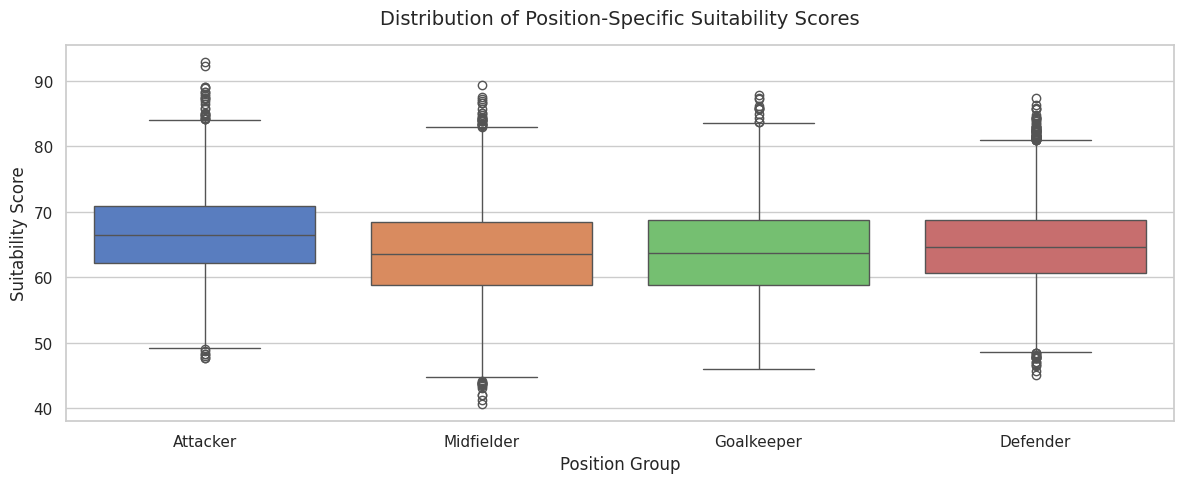

/tmp/ipykernel_16/247190917.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


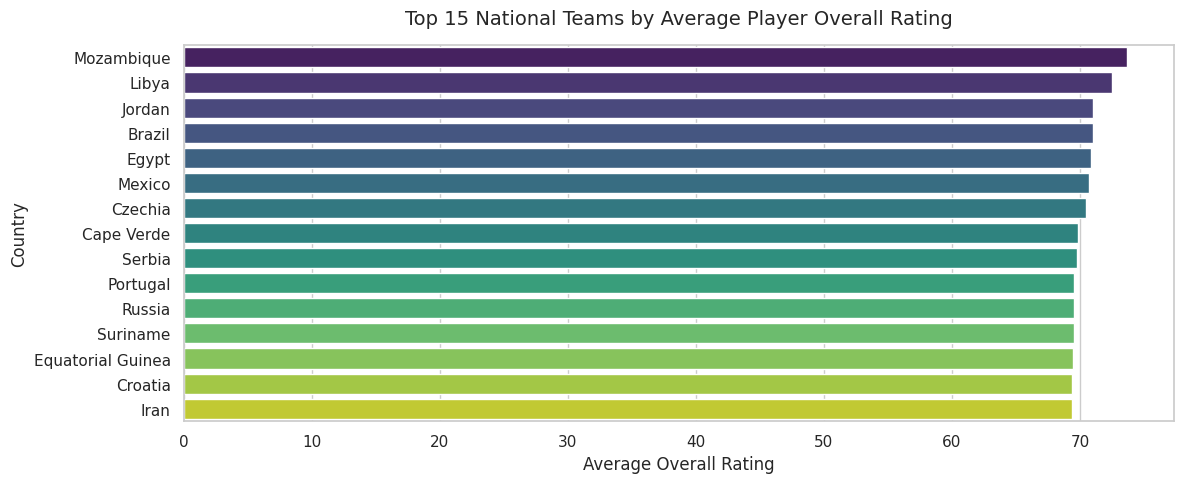

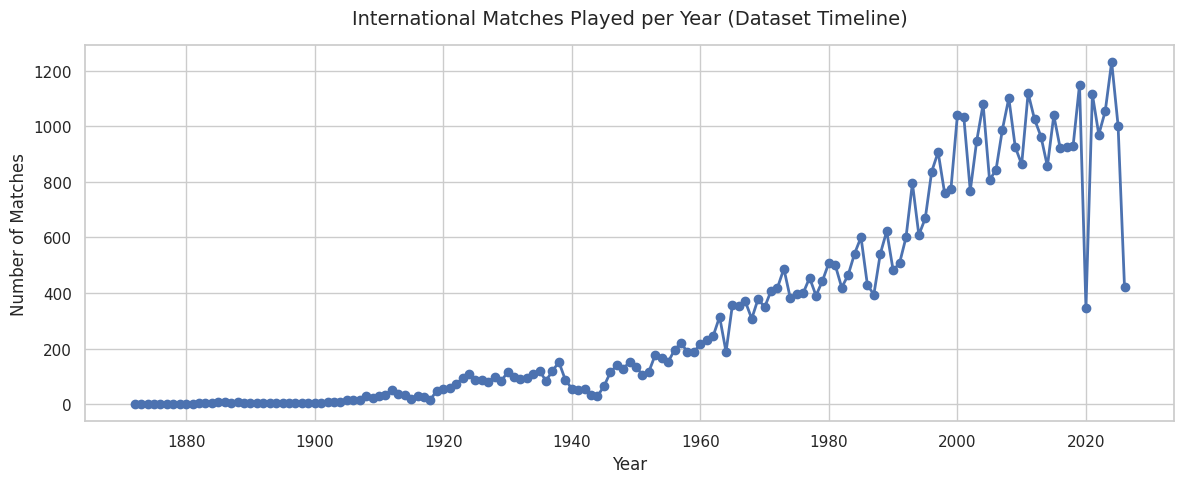

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional academic plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# --- Graph 1: Distribution of Player Suitability Scores by Position ---
plt.figure()
sns.boxplot(data=players, x='position_group', y='suitability_score', palette='muted')
plt.title('Distribution of Position-Specific Suitability Scores', fontsize=14, pad=15)
plt.xlabel('Position Group', fontsize=12)
plt.ylabel('Suitability Score', fontsize=12)
plt.tight_layout()
plt.show()

# --- Graph 2: Top 15 Countries by Average Player Overall Rating ---
plt.figure()
top_countries = players.groupby('country_std')['overall'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 15 National Teams by Average Player Overall Rating', fontsize=14, pad=15)
plt.xlabel('Average Overall Rating', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

# --- Graph 3: Historical Timeline of Match Dataset (Matches per Year) ---
plt.figure()
results['year'] = results['date'].dt.year
match_counts = results['year'].value_counts().sort_index()
plt.plot(match_counts.index, match_counts.values, marker='o', color='b', linewidth=2)
plt.title('International Matches Played per Year (Dataset Timeline)', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.tight_layout()
plt.show()

**3.2 Dataset Scope and Coverage**

3.2.1 Dataset Coverage Summary

In [20]:
import pandas as pd

# Load your cleaned datasets to count your global assets
players_df = pd.read_csv('/kaggle/working/players_clean.csv')
results_df = pd.read_csv('/kaggle/working/results_clean.csv')
ranking_df = pd.read_csv('/kaggle/working/latest_ranking_clean.csv')

# Calculate unique global metrics
unique_players = players_df['long_name'].nunique() if 'long_name' in players_df.columns else players_df.shape[0]
player_nationalities = players_df['nationality_name'].nunique() if 'nationality_name' in players_df.columns else "N/A"
unique_clubs = players_df['club_name'].nunique() if 'club_name' in players_df.columns else "N/A"

all_match_teams = pd.concat([results_df['home_team'], results_df['away_team']]).nunique()
ranked_countries = ranking_df['team_std'].nunique()

print("==================================================")
print("             GLOBAL DATA SCOPE AUDIT              ")
print("==================================================")
print(f" Total Unique Players Evaluated:      {unique_players}")
print(f" Player Nationalities Represented:    {player_nationalities}")
print(f" Domestic Club Teams Covered:         {unique_clubs}")
print(f" International Teams (Historical):    {all_match_teams}")
print(f" Active Regulated FIFA Countries:     {ranked_countries}")
print("==================================================")

             GLOBAL DATA SCOPE AUDIT              
 Total Unique Players Evaluated:      18329
 Player Nationalities Represented:    160
 Domestic Club Teams Covered:         671
 International Teams (Historical):    337
 Active Regulated FIFA Countries:     227


# 4. Machine Learning Model - Player Suitability

**4.1 Regression Model Libraries and Evaluation Metrics**

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**4.2 Player Feature Selection and Train-Test Preparation**

In [22]:
# Features used to predict position-specific suitability score
feature_cols = [
    'age', 'height_cm', 'weight_kg',
    'overall', 'potential',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys',
    
    'skill_dribbling', 'skill_curve', 'skill_long_passing', 'skill_ball_control',
    
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance',
    
    'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength',
    'power_long_shots',
    
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning',
    'mentality_vision', 'mentality_composure',
    
    'defending_marking_awareness', 'defending_standing_tackle',
    'defending_sliding_tackle',
    
    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking',
    'goalkeeping_positioning', 'goalkeeping_reflexes'
]

# Keep only columns that exist in your cleaned player dataset
feature_cols = [col for col in feature_cols if col in players.columns]

X = players[feature_cols + ['position_group']]
y = players['suitability_score']

numeric_features = feature_cols
categorical_features = ['position_group']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape)
print("Testing rows:", X_test.shape)

Training rows: (14680, 44)
Testing rows: (3670, 44)


**4.3 Train and Compare Player Suitability Regression Models**

In [23]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5)
}

model_results = []

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    model_results.append([model_name, mae, rmse, r2])
    trained_models[model_name] = pipeline

model_results_df = pd.DataFrame(
    model_results,
    columns=['Model', 'MAE', 'RMSE', 'R2 Score']
).sort_values(by='RMSE')

model_results_df

,Model,MAE,RMSE,R2 Score
2,Random Forest Regressor,0.636021,0.896362,0.982598
1,Decision Tree Regressor,1.055531,1.479736,0.952576
3,KNN Regressor,1.243262,1.615215,0.943495
0,Linear Regression,1.427053,1.866701,0.924529


**4.4 Regression Model Performance Comparison**

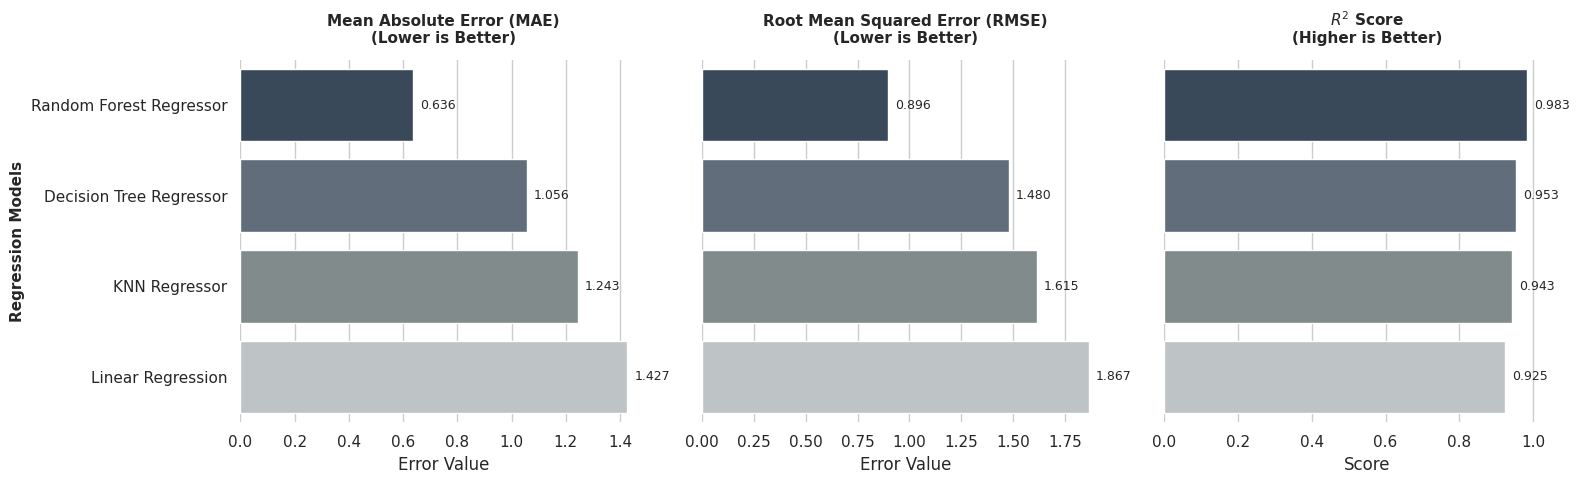

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, professional academic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Professional, low-saturation palette for an academic report layout
colors = ["#34495e", "#5d6d7e", "#7f8c8d", "#bdc3c7"]

# 2. Mean Absolute Error (MAE) Plot
sns.barplot(x='MAE', y='Model', data=model_results_df, ax=axes[0], palette=colors, hue='Model', legend=False)
axes[0].set_title('Mean Absolute Error (MAE)\n(Lower is Better)', fontsize=11, fontweight='bold', pad=12)
axes[0].set_xlabel('Error Value')
axes[0].set_ylabel('Regression Models', fontsize=11, fontweight='bold')

# 3. Root Mean Squared Error (RMSE) Plot
sns.barplot(x='RMSE', y='Model', data=model_results_df, ax=axes[1], palette=colors, hue='Model', legend=False)
axes[1].set_title('Root Mean Squared Error (RMSE)\n(Lower is Better)', fontsize=11, fontweight='bold', pad=12)
axes[1].set_xlabel('Error Value')
axes[1].set_ylabel('')

# 4. R² Score Plot
sns.barplot(x='R2 Score', y='Model', data=model_results_df, ax=axes[2], palette=colors, hue='Model', legend=False)
axes[2].set_title('$R^2$ Score\n(Higher is Better)', fontsize=11, fontweight='bold', pad=12)
axes[2].set_xlabel('Score')
axes[2].set_ylabel('')
axes[2].set_xlim(0, 1.1)  # Keeps the scale normalized up to 1.0+

# Add value annotations on top of the bars for precise reading
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=5, fontsize=9)

# Clean up layout and borders
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Display the final plot
plt.show()

4.4.1 RMSE-Based Regression Model Visualisation

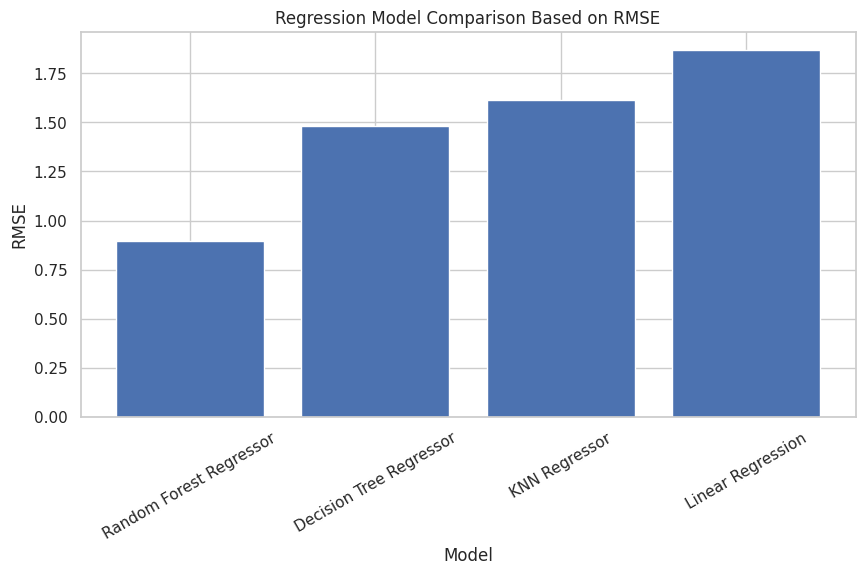

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(model_results_df['Model'], model_results_df['RMSE'])
plt.title('Regression Model Comparison Based on RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=30)
plt.show()

**4.5 Select Best Player Suitability Model**

In [26]:
best_model_name = model_results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("Best model selected:", best_model_name)

players['ml_suitability_score'] = best_model.predict(players[feature_cols + ['position_group']])

players[['short_name', 'country_std', 'club_name', 'league_name',
         'primary_position', 'position_group', 'overall',
         'suitability_score', 'ml_suitability_score']].head(20)

Best model selected: Random Forest Regressor


,short_name,country_std,club_name,league_name,primary_position,position_group,overall,suitability_score,ml_suitability_score
0,K. Mbappé,France,Paris Saint Germain,Ligue 1,ST,Attacker,91,92.85,88.7040
1,E. Haaland,Norway,Manchester City,Premier League,ST,Attacker,91,92.20,90.1085
2,K. De Bruyne,Belgium,Manchester City,Premier League,CM,Midfielder,91,89.30,88.5975
3,L. Messi,Argentina,Inter Miami,Major League Soccer,CF,Attacker,90,87.70,87.1245
4,K. Benzema,France,Al Ittihad,Pro League,CF,Attacker,90,87.90,88.1205
5,R. Lewandowski,Poland,FC Barcelona,La Liga,ST,Attacker,90,89.00,89.0230
6,T. Courtois,Belgium,Real Madrid,La Liga,GK,Goalkeeper,90,87.75,87.4060
7,H. Kane,England,FC Bayern München,Bundesliga,ST,Attacker,90,88.80,88.7100
8,Vini Jr.,Brazil,Real Madrid,La Liga,LW,Attacker,89,87.20,86.1615
9,Alisson,Brazil,Liverpool,Premier League,GK,Goalkeeper,89,87.20,86.9615


# 5. Starting XI Recommendation System

**5.1 Starting XI Recommendation Functions**

In [27]:
def get_team_players(entity_name, entity_type='country'):
    if entity_type == 'country':
        return players[players['country_std'] == entity_name].copy()

    if entity_type == 'club':
        return players[players['club_name'] == entity_name].copy()

    if entity_type == 'league':
        return players[players['league_name'] == entity_name].copy()

    raise ValueError(
        "entity_type must be 'country', 'club', or 'league'"
    )


def parse_formation(formation):
    formation = str(formation).strip()

    try:
        numbers = [
            int(x)
            for x in formation.split('-')
        ]

    except ValueError as exc:
        raise ValueError(
            "Formation must contain numbers separated by hyphens."
        ) from exc

    if len(numbers) < 3:
        raise ValueError(
            "Formation must have at least 3 parts, "
            "for example '4-3-3'."
        )

    if sum(numbers) != 10:
        raise ValueError(
            f"Invalid formation '{formation}'. "
            "The outfield numbers must total 10."
        )

    return (
        numbers[0],
        sum(numbers[1:-1]),
        numbers[-1]
    )


def _formation_slot_spec(formation):
    """
    Define realistic tactical slots for common formations.
    Secondary EA FC positions are also accepted.
    """

    formation = str(formation).strip()

    specs = {

        '4-3-3': [
            ('GK', 'Goalkeeper', ['GK']),

            ('LB', 'Defender', ['LB', 'LWB']),
            ('LCB', 'Defender', ['CB']),
            ('RCB', 'Defender', ['CB']),
            ('RB', 'Defender', ['RB', 'RWB']),

            ('LCM', 'Midfielder', ['CM', 'CDM', 'CAM', 'LM']),
            ('CM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('RCM', 'Midfielder', ['CM', 'CDM', 'CAM', 'RM']),

            ('LW', 'Attacker', ['LW', 'LM', 'CF']),
            ('ST', 'Attacker', ['ST', 'CF']),
            ('RW', 'Attacker', ['RW', 'RM', 'CF'])
        ],

        '4-4-2': [
            ('GK', 'Goalkeeper', ['GK']),

            ('LB', 'Defender', ['LB', 'LWB']),
            ('LCB', 'Defender', ['CB']),
            ('RCB', 'Defender', ['CB']),
            ('RB', 'Defender', ['RB', 'RWB']),

            ('LM', 'Midfielder', ['LM', 'LW', 'CM']),
            ('LCM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('RCM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('RM', 'Midfielder', ['RM', 'RW', 'CM']),

            ('LST', 'Attacker', ['ST', 'CF']),
            ('RST', 'Attacker', ['ST', 'CF'])
        ],

        '4-2-3-1': [
            ('GK', 'Goalkeeper', ['GK']),

            ('LB', 'Defender', ['LB', 'LWB']),
            ('LCB', 'Defender', ['CB']),
            ('RCB', 'Defender', ['CB']),
            ('RB', 'Defender', ['RB', 'RWB']),

            ('LCDM', 'Midfielder', ['CDM', 'CM']),
            ('RCDM', 'Midfielder', ['CDM', 'CM']),

            ('LW', 'Midfielder', ['LW', 'LM', 'CAM', 'CM']),
            ('CAM', 'Midfielder', ['CAM', 'CM', 'CF']),
            ('RW', 'Midfielder', ['RW', 'RM', 'CAM', 'CM']),

            ('ST', 'Attacker', ['ST', 'CF'])
        ],

        '3-4-3': [
            ('GK', 'Goalkeeper', ['GK']),

            ('LCB', 'Defender', ['CB', 'LB']),
            ('CB', 'Defender', ['CB']),
            ('RCB', 'Defender', ['CB', 'RB']),

            ('LM', 'Midfielder', ['LM', 'LWB', 'LW', 'CM']),
            ('LCM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('RCM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('RM', 'Midfielder', ['RM', 'RWB', 'RW', 'CM']),

            ('LW', 'Attacker', ['LW', 'LM', 'CF']),
            ('ST', 'Attacker', ['ST', 'CF']),
            ('RW', 'Attacker', ['RW', 'RM', 'CF'])
        ],

        '3-5-2': [
            ('GK', 'Goalkeeper', ['GK']),

            ('LCB', 'Defender', ['CB', 'LB']),
            ('CB', 'Defender', ['CB']),
            ('RCB', 'Defender', ['CB', 'RB']),

            ('LWB', 'Midfielder', ['LWB', 'LM', 'LB', 'LW']),
            ('LCM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('CM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('RCM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('RWB', 'Midfielder', ['RWB', 'RM', 'RB', 'RW']),

            ('LST', 'Attacker', ['ST', 'CF']),
            ('RST', 'Attacker', ['ST', 'CF'])
        ],

        '5-3-2': [
            ('GK', 'Goalkeeper', ['GK']),

            ('LWB', 'Defender', ['LWB', 'LB']),
            ('LCB', 'Defender', ['CB', 'LB']),
            ('CB', 'Defender', ['CB']),
            ('RCB', 'Defender', ['CB', 'RB']),
            ('RWB', 'Defender', ['RWB', 'RB']),

            ('LCM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('CM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('RCM', 'Midfielder', ['CM', 'CDM', 'CAM']),

            ('LST', 'Attacker', ['ST', 'CF']),
            ('RST', 'Attacker', ['ST', 'CF'])
        ],

        '3-3-4': [
            ('GK', 'Goalkeeper', ['GK']),

            ('LCB', 'Defender', ['CB', 'LB']),
            ('CB', 'Defender', ['CB']),
            ('RCB', 'Defender', ['CB', 'RB']),

            ('LM', 'Midfielder', ['LM', 'CM', 'LWB']),
            ('CM', 'Midfielder', ['CM', 'CDM', 'CAM']),
            ('RM', 'Midfielder', ['RM', 'CM', 'RWB']),

            ('LW', 'Attacker', ['LW', 'LM', 'CF']),
            ('LST', 'Attacker', ['ST', 'CF']),
            ('RST', 'Attacker', ['ST', 'CF']),
            ('RW', 'Attacker', ['RW', 'RM', 'CF'])
        ]
    }

    if formation in specs:
        return specs[formation]

    # Fallback for another valid formation
    defenders, midfielders, attackers = parse_formation(
        formation
    )

    fallback = [
        ('GK', 'Goalkeeper', ['GK'])
    ]

    fallback += [
        (
            f'D{i + 1}',
            'Defender',
            ['CB', 'LB', 'RB', 'LWB', 'RWB']
        )
        for i in range(defenders)
    ]

    fallback += [
        (
            f'M{i + 1}',
            'Midfielder',
            ['CM', 'CDM', 'CAM', 'LM', 'RM']
        )
        for i in range(midfielders)
    ]

    fallback += [
        (
            f'A{i + 1}',
            'Attacker',
            ['ST', 'CF', 'LW', 'RW']
        )
        for i in range(attackers)
    ]

    return fallback


def _position_set(position_text):
    """
    Convert 'ST, LW' into {'ST', 'LW'}.
    """

    if pd.isna(position_text):
        return set()

    return {
        x.strip()
        for x in str(position_text).split(',')
        if x.strip()
    }


def _mean_attributes(
    frame,
    columns,
    default=50.0
):
    existing = [
        c
        for c in columns
        if c in frame.columns
    ]

    if frame.empty or not existing:
        return float(default)

    values = frame[
        existing
    ].apply(
        pd.to_numeric,
        errors='coerce'
    )

    value = (
        values
        .mean(axis=1)
        .mean()
    )

    if pd.isna(value):
        return float(default)

    return float(value)


def _top_group_players(
    frame,
    group,
    n=5
):
    pool = frame[
        frame['position_group'] == group
    ].copy()

    if pool.empty:
        return pool

    if 'ml_suitability_score' in pool.columns:
        rank_col = 'ml_suitability_score'
    else:
        rank_col = 'overall'

    pool[rank_col] = pd.to_numeric(
        pool[rank_col],
        errors='coerce'
    ).fillna(0)

    return pool.nlargest(
        min(n, len(pool)),
        rank_col
    )


def build_opponent_profile(
    opponent_name,
    entity_type='country'
):
    opponent_players = get_team_players(
        opponent_name,
        entity_type
    )

    if opponent_players.empty:
        return None

    attackers = _top_group_players(
        opponent_players,
        'Attacker',
        5
    )

    midfielders = _top_group_players(
        opponent_players,
        'Midfielder',
        5
    )

    defenders = _top_group_players(
        opponent_players,
        'Defender',
        5
    )

    return {

        'attack_speed': _mean_attributes(
            attackers,
            [
                'pace',
                'movement_acceleration',
                'movement_sprint_speed'
            ]
        ),

        'attack_finishing': _mean_attributes(
            attackers,
            [
                'shooting',
                'attacking_finishing',
                'mentality_positioning',
                'power_shot_power'
            ]
        ),

        'midfield_control': _mean_attributes(
            midfielders,
            [
                'passing',
                'attacking_short_passing',
                'mentality_vision',
                'skill_dribbling'
            ]
        ),

        'defence_quality': _mean_attributes(
            defenders,
            [
                'defending',
                'defending_standing_tackle',
                'mentality_interceptions',
                'physic'
            ]
        ),

        'defence_speed': _mean_attributes(
            defenders,
            [
                'pace',
                'movement_acceleration',
                'movement_sprint_speed'
            ]
        )
    }


def _weighted_player_score(
    frame,
    weights
):
    score = pd.Series(
        0.0,
        index=frame.index
    )

    total_weight = 0.0

    for column, weight in weights.items():

        if (
            column in frame.columns
            and weight > 0
        ):

            values = pd.to_numeric(
                frame[column],
                errors='coerce'
            ).fillna(0)

            score = (
                score
                + values * weight
            )

            total_weight += weight

    if total_weight == 0:

        return pd.to_numeric(
            frame['ml_suitability_score'],
            errors='coerce'
        ).fillna(0)

    return score / total_weight


def add_opponent_adjusted_scores(
    team_players,
    opponent_name=None,
    entity_type='country'
):
    scored = team_players.copy()

    base = pd.to_numeric(
        scored['ml_suitability_score'],
        errors='coerce'
    ).fillna(0)

    scored[
        'opponent_adjusted_score'
    ] = base

    if not opponent_name:
        return scored

    profile = build_opponent_profile(
        opponent_name,
        entity_type
    )

    if profile is None:

        print(
            f"Warning: opponent profile unavailable for "
            f"{opponent_name}; base ML scores used."
        )

        return scored

    attack_speed = (
        profile['attack_speed'] / 100.0
    )

    attack_finishing = (
        profile['attack_finishing'] / 100.0
    )

    midfield_control = (
        profile['midfield_control'] / 100.0
    )

    defence_quality = (
        profile['defence_quality'] / 100.0
    )

    defence_speed = (
        profile['defence_speed'] / 100.0
    )

    role_weights = {

        'Goalkeeper': {
            'goalkeeping_reflexes':
                0.20 + 0.20 * attack_speed,

            'goalkeeping_handling':
                0.18 + 0.15 * attack_finishing,

            'goalkeeping_positioning':
                0.18 + 0.15 * attack_finishing,

            'goalkeeping_diving':
                0.18 + 0.10 * attack_speed,

            'goalkeeping_kicking': 0.10,

            'overall': 0.10
        },

        'Defender': {
            'defending':
                0.20 + 0.18 * attack_finishing,

            'defending_standing_tackle':
                0.15 + 0.10 * attack_finishing,

            'mentality_interceptions':
                0.15 + 0.10 * midfield_control,

            'pace':
                0.10 + 0.22 * attack_speed,

            'physic': 0.12,

            'attacking_heading_accuracy': 0.08,

            'overall': 0.08
        },

        'Midfielder': {
            'passing': 0.18,

            'attacking_short_passing': 0.14,

            'mentality_vision': 0.10,

            'skill_dribbling': 0.10,

            'defending':
                0.10 + 0.16 * midfield_control,

            'mentality_interceptions':
                0.08 + 0.16 * midfield_control,

            'power_stamina':
                0.10 + 0.10 * attack_speed,

            'overall': 0.08
        },

        'Attacker': {
            'attacking_finishing':
                0.20 + 0.15 * defence_quality,

            'shooting': 0.15,

            'skill_dribbling':
                0.12 + 0.18 * defence_quality,

            'pace':
                0.12 + 0.18 * defence_speed,

            'mentality_positioning': 0.12,

            'power_shot_power': 0.10,

            'overall': 0.08
        }
    }

    for group, weights in role_weights.items():

        mask = (
            scored['position_group']
            == group
        )

        if not mask.any():
            continue

        tactical_score = (
            _weighted_player_score(
                scored.loc[mask],
                weights
            )
        )

        scored.loc[
            mask,
            'opponent_adjusted_score'
        ] = (
            0.65 * base.loc[mask]
            + 0.35 * tactical_score
        )

    return scored


def _select_xi_by_score(
    team_players,
    formation,
    score_col
):
    """
    Select a football-position-aware XI.

    The system first chooses players whose EA FC
    listed positions match the tactical slot.
    Broad position-group fallback is used only
    if no compatible player is available.
    """

    pool = team_players.copy()

    pool[score_col] = pd.to_numeric(
        pool[score_col],
        errors='coerce'
    ).fillna(0)

    if 'overall' in pool.columns:

        pool['overall'] = pd.to_numeric(
            pool['overall'],
            errors='coerce'
        ).fillna(0)

    if 'player_id' in pool.columns:

        unique_col = 'player_id'

    elif 'long_name' in pool.columns:

        unique_col = 'long_name'

    else:

        unique_col = 'short_name'

    selected_rows = []

    used_players = set()

    slot_spec = _formation_slot_spec(
        formation
    )

    for (
        slot,
        group,
        compatible_positions
    ) in slot_spec:

        available = pool[
            (
                pool['position_group']
                == group
            )
            &
            (
                ~pool[unique_col]
                .isin(used_players)
            )
        ].copy()

        if available.empty:
            continue

        compatible_mask = (
            available[
                'player_positions'
            ]
            .apply(
                lambda value:
                bool(
                    _position_set(
                        value
                    )
                    .intersection(
                        compatible_positions
                    )
                )
            )
        )

        candidates = available[
            compatible_mask
        ].copy()

        used_fallback = False

        if candidates.empty:

            candidates = (
                available.copy()
            )

            used_fallback = True

        sort_columns = [
            score_col
        ]

        ascending = [
            False
        ]

        if (
            'overall'
            in candidates.columns
            and score_col != 'overall'
        ):

            sort_columns.append(
                'overall'
            )

            ascending.append(
                False
            )

        chosen = (
            candidates
            .sort_values(
                sort_columns,
                ascending=ascending
            )
            .head(1)
            .copy()
        )

        chosen[
            'selected_slot'
        ] = slot

        chosen[
            'slot_match'
        ] = (
            'Group fallback'
            if used_fallback
            else 'Compatible position'
        )

        selected_rows.append(
            chosen
        )

        used_players.add(
            chosen.iloc[0][
                unique_col
            ]
        )

    if not selected_rows:

        return (
            pool.iloc[0:0]
            .copy()
        )

    best_xi = pd.concat(
        selected_rows,
        ignore_index=False
    )

    return best_xi


def recommend_best_xi(
    entity_name,
    entity_type='country',
    formation='4-3-3',
    opponent_name=None,
    verbose=True
):
    """
    Final XI recommendation combines:

    1. ML suitability
    2. opponent tactical adjustment
    3. formation-specific position compatibility
    """

    team_players = get_team_players(
        entity_name,
        entity_type
    )

    if team_players.empty:

        if verbose:

            print(
                f"No players found for "
                f"{entity_name}. "
                "Check spelling."
            )

        return pd.DataFrame()

    team_players = (
        add_opponent_adjusted_scores(
            team_players,
            opponent_name=opponent_name,
            entity_type=entity_type
        )
    )

    best_xi = (
        _select_xi_by_score(
            team_players,
            formation=formation,
            score_col=
            'opponent_adjusted_score'
        )
    )

    if (
        len(best_xi) < 11
        and verbose
    ):

        print(
            f"Warning: only "
            f"{len(best_xi)} players "
            f"selected for "
            f"{entity_name}. "
            "The dataset may not "
            "contain enough players "
            "for this formation."
        )

    output_cols = [
        'player_id',
        'short_name',
        'long_name',
        'country_std',
        'club_name',
        'league_name',
        'player_positions',
        'primary_position',
        'position_group',
        'selected_slot',
        'slot_match',
        'overall',
        'ml_suitability_score',
        'opponent_adjusted_score'
    ]

    output_cols = [
        column
        for column in output_cols
        if column in best_xi.columns
    ]

    best_xi = best_xi[
        output_cols
    ].copy()

    if verbose:

        if opponent_name:

            print(
                f"{entity_name} "
                f"Best XI vs "
                f"{opponent_name} "
                f"using {formation}"
            )

        else:

            print(
                f"{entity_name} "
                f"Best XI using "
                f"{formation}"
            )

    return best_xi

**5.2 Example Starting XI Recommendation**

In [28]:
argentina_xi = recommend_best_xi('Argentina', entity_type='country', formation='4-3-3')
argentina_xi

Argentina Best XI using 4-3-3


,player_id,short_name,long_name,country_std,club_name,league_name,player_positions,primary_position,position_group,selected_slot,slot_match,overall,ml_suitability_score,opponent_adjusted_score
80,202811,E. Martínez,Damián Emiliano Martínez,Argentina,Aston Villa,Premier League,GK,GK,Goalkeeper,GK,Compatible position,85,83.4850,83.4850
90,224334,M. Acuña,Marcos Javier Acuña,Argentina,Sevilla,La Liga,"LB, LM",LB,Defender,LB,Compatible position,85,80.1620,80.1620
98,239301,L. Martínez,Lisandro Martínez,Argentina,Manchester United,Premier League,CB,CB,Defender,LCB,Compatible position,84,82.5275,82.5275
208,232488,C. Romero,Cristian Gabriel Romero,Argentina,Tottenham Hotspur,Premier League,CB,CB,Defender,RCB,Compatible position,82,81.4430,81.4430
378,237221,J. Foyth,Juan Marcos Foyth,Argentina,Villarreal,La Liga,"RB, CB, CDM",RB,Defender,RB,Compatible position,80,78.8570,78.8570
137,212616,R. De Paul,Rodrigo Javier De Paul,Argentina,Atlético Madrid,La Liga,CM,CM,Midfielder,LCM,Compatible position,84,82.5290,82.5290
144,247090,E. Fernández,Enzo Jeremías Fernández,Argentina,Chelsea,Premier League,"CM, CDM",CM,Midfielder,CM,Compatible position,83,82.0360,82.0360
228,239837,A. Mac Allister,Alexis Mac Allister,Argentina,Liverpool,Premier League,"CM, CAM, CDM",CM,Midfielder,RCM,Compatible position,82,81.4085,81.4085
3,158023,L. Messi,Lionel Andrés Messi Cuccittini,Argentina,Inter Miami,Major League Soccer,"CF, CAM",CF,Attacker,LW,Compatible position,90,87.1245,87.1245
28,231478,L. Martínez,Lautaro Javier Martínez,Argentina,Inter,Serie A,ST,ST,Attacker,ST,Compatible position,87,86.7630,86.7630


**5.3 Starting XI Evaluation and Top-Rated Player Comparison**

In [29]:
def evaluate_recommended_xi(
    entity_name,
    formation='4-3-3',
    opponent_name=None,
    entity_type='country',
    recommended_xi=None,
    show_tables=True
):
    """
    Evaluate position accuracy and compare the
    recommended XI with the highest-rated XI.
    """

    team_players = get_team_players(
        entity_name,
        entity_type
    )

    if team_players.empty:

        print(
            f"No player data found for {entity_name}."
        )

        return None

    if recommended_xi is None:

        recommended_xi = recommend_best_xi(
            entity_name,
            entity_type=entity_type,
            formation=formation,
            opponent_name=opponent_name,
            verbose=False
        )

    (
        defenders_count,
        midfielders_count,
        attackers_count
    ) = parse_formation(formation)

    expected_counts = {
        'Goalkeeper': 1,
        'Defender': defenders_count,
        'Midfielder': midfielders_count,
        'Attacker': attackers_count
    }

    actual_counts = (
        recommended_xi[
            'position_group'
        ]
        .value_counts()
        .to_dict()
    )

    correct_slots = sum(
        min(
            actual_counts.get(group, 0),
            expected
        )
        for group, expected
        in expected_counts.items()
    )

    position_accuracy = (
        correct_slots / 11
    ) * 100

    # Prepare a second XI using only overall rating.
    top_rated_pool = team_players.copy()

    top_rated_pool['overall'] = pd.to_numeric(
        top_rated_pool['overall'],
        errors='coerce'
    ).fillna(0)

    top_rated_xi = _select_xi_by_score(
        top_rated_pool,
        formation=formation,
        score_col='overall'
    )

    recommended_avg_overall = (
        recommended_xi['overall'].mean()
    )

    top_rated_avg_overall = (
        top_rated_xi['overall'].mean()
    )

    recommended_avg_ml = (
        recommended_xi[
            'ml_suitability_score'
        ].mean()
    )

    top_rated_avg_ml = (
        top_rated_xi[
            'ml_suitability_score'
        ].mean()
    )

    # Use player_id because different players may share
# the same short name, such as L. Martínez.
    id_column = (
        'player_id'
        if 'player_id' in recommended_xi.columns
        and 'player_id' in top_rated_xi.columns
        else 'long_name'
    )
    
    recommended_ids = set(
        recommended_xi[id_column]
    )
    
    top_rated_ids = set(
        top_rated_xi[id_column]
    )
    
    overlap_count = len(
        recommended_ids.intersection(
            top_rated_ids
        )
    )
    
    duplicate_count = int(
        recommended_xi[
            id_column
        ].duplicated().sum()
    )

    role_check = pd.DataFrame([

        {
            'Position Group': group,
            'Required': required,
            'Selected': actual_counts.get(group, 0),
            'Correct':
                actual_counts.get(group, 0)
                == required
        }

        for group, required
        in expected_counts.items()
    ])

    comparison = pd.DataFrame({

        'Metric': [
            'Selected players',
            'Position accuracy (%)',
            'Formation complete',
            'Duplicate players',
            'Recommended XI average overall',
            'Top-rated XI average overall',
            'Recommended XI average ML suitability',
            'Top-rated XI average ML suitability',
            'Players common to both XIs'
        ],

        'Result': [
            len(recommended_xi),
            round(position_accuracy, 2),

            (
                len(recommended_xi) == 11
                and position_accuracy == 100
            ),

            duplicate_count,
            round(recommended_avg_overall, 2),
            round(top_rated_avg_overall, 2),
            round(recommended_avg_ml, 2),
            round(top_rated_avg_ml, 2),
            f"{overlap_count}/11"
        ]
    })

    top_rated_cols = [
        'player_id',
        'short_name',
        'long_name',
        'primary_position',
        'position_group',
        'overall',
        'ml_suitability_score'
        ]

    top_rated_cols = [
        column
        for column in top_rated_cols
        if column in top_rated_xi.columns
    ]

    top_rated_xi = top_rated_xi[
        top_rated_cols
    ].copy()

    if show_tables:

        print(
            f"\nEVALUATION: "
            f"{entity_name} ({formation})"
        )

        print("--------------------------------")

        display(role_check)
        display(comparison)

        print(
            "\nHighest-rated XI "
            "used for comparison"
        )

        display(top_rated_xi)

    return {

        'role_check': role_check,

        'comparison': comparison,

        'top_rated_xi': top_rated_xi,

        'position_accuracy':
            position_accuracy,

        'overlap_count':
            overlap_count
    }

**5.4 Club Starting XI Demonstration**

In [30]:
real_madrid_xi = recommend_best_xi('Real Madrid', entity_type='club', formation='4-3-3')
real_madrid_xi

Real Madrid Best XI using 4-3-3


,player_id,short_name,long_name,country_std,club_name,league_name,player_positions,primary_position,position_group,selected_slot,slot_match,overall,ml_suitability_score,opponent_adjusted_score
6,192119,T. Courtois,Thibaut Nicolas Marc Courtois,Belgium,Real Madrid,La Liga,GK,GK,Goalkeeper,GK,Compatible position,90,87.4060,87.4060
78,197445,D. Alaba,David Olatukunbo Alaba,Austria,Real Madrid,La Liga,"CB, LB",CB,Defender,LB,Compatible position,85,82.1055,82.1055
43,240130,Éder Militão,Éder Gabriel Militão,Brazil,Real Madrid,La Liga,CB,CB,Defender,LCB,Compatible position,86,84.9205,84.9205
81,205452,A. Rüdiger,Antonio Rüdiger,Germany,Real Madrid,La Liga,CB,CB,Defender,RCB,Compatible position,85,83.3035,83.3035
178,200724,Nacho Fernández,José Ignacio Fernández Iglesias,Spain,Real Madrid,La Liga,"CB, LB, RB",CB,Defender,RB,Compatible position,83,81.3620,81.3620
33,177003,L. Modrić,Luka Modrić,Croatia,Real Madrid,La Liga,CM,CM,Midfielder,LCM,Compatible position,87,86.2135,86.2135
17,239053,F. Valverde,Federico Santiago Valverde Dipetta,Uruguay,Real Madrid,La Liga,"CM, RW",CM,Midfielder,CM,Compatible position,88,85.4560,85.4560
39,252371,J. Bellingham,Jude Victor William Bellingham,England,Real Madrid,La Liga,"CM, CAM",CM,Midfielder,RCM,Compatible position,86,83.8670,83.8670
8,238794,Vini Jr.,Vinícius José Paixão de Oliveira Júnior,Brazil,Real Madrid,La Liga,LW,LW,Attacker,LW,Compatible position,89,86.1615,86.1615
61,243812,Rodrygo,Rodrygo Silva de Goes,Brazil,Real Madrid,La Liga,"RW, LW, ST",RW,Attacker,ST,Compatible position,85,83.6960,83.6960


**5.5 League Starting XI Demonstration**

In [31]:
premier_league_xi = recommend_best_xi('Premier League', entity_type='league', formation='4-2-3-1')
premier_league_xi

Premier League Best XI using 4-2-3-1


,player_id,short_name,long_name,country_std,club_name,league_name,player_positions,primary_position,position_group,selected_slot,slot_match,overall,ml_suitability_score,opponent_adjusted_score
9,212831,Alisson,Alisson Ramsés Becker,Brazil,Liverpool,Premier League,GK,GK,Goalkeeper,GK,Compatible position,89,86.9615,86.9615
201,251517,J. Gvardiol,Joško Gvardiol,Croatia,Manchester City,Premier League,"CB, LB",CB,Defender,LB,Compatible position,82,81.6645,81.6645
15,203376,V. van Dijk,Virgil van Dijk,Netherlands,Liverpool,Premier League,CB,CB,Defender,LCB,Compatible position,89,86.7755,86.7755
11,239818,Rúben Dias,Rúben dos Santos Gato Alves Dias,Portugal,Manchester City,Premier League,CB,CB,Defender,RCB,Compatible position,89,85.3335,85.3335
70,203574,J. Stones,John Stones,England,Manchester City,Premier League,"CB, RB",CB,Defender,RB,Compatible position,85,82.7090,82.7090
2,192985,K. De Bruyne,Kevin De Bruyne,Belgium,Manchester City,Premier League,"CM, CAM",CM,Midfielder,LCDM,Compatible position,91,88.5975,88.5975
23,212198,Bruno Fernandes,Bruno Miguel Borges Fernandes,Portugal,Manchester United,Premier League,"CAM, CM",CAM,Midfielder,RCDM,Compatible position,88,87.2150,87.2150
24,218667,Bernardo Silva,Bernardo Mota Veiga de Carvalho e Silva,Portugal,Manchester City,Premier League,"CM, RW",CM,Midfielder,LW,Compatible position,88,86.6930,86.6930
25,222665,M. Ødegaard,Martin Ødegaard,Norway,Arsenal,Premier League,"CAM, CM",CAM,Midfielder,CAM,Compatible position,87,85.5380,85.5380
10,231866,Rodri,Rodrigo Hernández Cascante,Spain,Manchester City,Premier League,"CDM, CM",CDM,Midfielder,RW,Compatible position,89,84.9470,84.9470


**5.6 Available League Verification**

In [32]:
players['league_name'].dropna().sort_values().unique()[:100]

array(['1. Division', '1. HNL', '2. Bundesliga', '3. Liga', 'A-League',
       'Allsvenskan', 'Bundesliga', 'Championship', 'Ekstraklasa',
       'Eliteserien', 'Eredivisie', 'Fortuna Liga', 'Jupiler Pro League',
       'K League 1', 'La Liga', 'La Liga 2', 'League One', 'League Two',
       'Liga 1', 'Liga BetPlay', 'Liga De Futbol Prof', 'Liga Portugal',
       'Liga Pro', 'Liga Profesional', 'Ligue 1', 'Ligue 2',
       'Major League Soccer', 'NB I.', 'Premier Division',
       'Premier League', 'Premiership', 'Primera Division',
       'Primera División', 'Pro League', 'Serie A', 'Serie B',
       'Super League', 'Super Lig', 'Superliga', 'Unknown',
       'Veikkausliiga'], dtype=object)

# 6. Team Strength and Opponent Comparison

**6.1 Opponent-Adjusted Team Strength Comparison**

In [33]:
def compare_two_teams(
    team_1,
    team_2,
    entity_type='country',
    formation='4-3-3'
):
    """
    Compare two opponent-adjusted recommended XIs.
    """

    team_1_xi = recommend_best_xi(
        team_1,
        entity_type=entity_type,
        formation=formation,
        opponent_name=team_2
    )

    team_2_xi = recommend_best_xi(
        team_2,
        entity_type=entity_type,
        formation=formation,
        opponent_name=team_1
    )

    if team_1_xi.empty or team_2_xi.empty:

        print(
            "Cannot compare because one team "
            "has no player data."
        )

        return None

    # Original ML suitability remains the standard
    # strength score for both teams.
    team_1_strength = (
        team_1_xi[
            'ml_suitability_score'
        ].mean()
    )

    team_2_strength = (
        team_2_xi[
            'ml_suitability_score'
        ].mean()
    )

    # Opponent-adjusted scores indicate tactical fit.
    team_1_fit = (
        team_1_xi[
            'opponent_adjusted_score'
        ].mean()
    )

    team_2_fit = (
        team_2_xi[
            'opponent_adjusted_score'
        ].mean()
    )

    print("================================================")
    print(f"Formation: {formation}")

    print(
        f"{team_1} XI Strength: "
        f"{team_1_strength:.2f}"
    )

    print(
        f"{team_1} Tactical Fit vs "
        f"{team_2}: {team_1_fit:.2f}"
    )

    print(
        f"{team_2} XI Strength: "
        f"{team_2_strength:.2f}"
    )

    print(
        f"{team_2} Tactical Fit vs "
        f"{team_1}: {team_2_fit:.2f}"
    )

    print("================================================")

    if team_1_strength > team_2_strength:

        print(
            f"{team_1} has the stronger selected XI "
            "based on player attributes."
        )

    elif team_2_strength > team_1_strength:

        print(
            f"{team_2} has the stronger selected XI "
            "based on player attributes."
        )

    else:

        print(
            "Both selected XIs have equal strength."
        )

    return team_1_xi, team_2_xi

**6.2 Argentina vs France Team Comparison**

In [34]:
argentina_xi, france_xi = compare_two_teams(
    'Argentina',
    'France',
    entity_type='country',
    formation='4-3-3'
)

Argentina Best XI vs France using 4-3-3
France Best XI vs Argentina using 4-3-3
Formation: 4-3-3
Argentina XI Strength: 82.70
Argentina Tactical Fit vs France: 82.53
France XI Strength: 84.28
France Tactical Fit vs Argentina: 84.43
France has the stronger selected XI based on player attributes.


**6.3 Club Team Comparison Demonstration**

In [35]:
real_xi, barca_xi = compare_two_teams('Real Madrid', 'FC Barcelona', entity_type='club', formation='4-3-3')

Real Madrid Best XI vs FC Barcelona using 4-3-3
FC Barcelona Best XI vs Real Madrid using 4-3-3
Formation: 4-3-3
Real Madrid XI Strength: 82.98
Real Madrid Tactical Fit vs FC Barcelona: 83.06
FC Barcelona XI Strength: 83.28
FC Barcelona Tactical Fit vs Real Madrid: 83.18
FC Barcelona has the stronger selected XI based on player attributes.


# 7. Match Outcome Prediction

**7.1 Calculate National Team XI Strength**

In [36]:
def get_national_xi_strength(
    country_name,
    formation='4-3-3'
):
    """
    Produce a neutral/base national XI strength
    for training the historical match model.
    """

    xi = recommend_best_xi(
        country_name,
        entity_type='country',
        formation=formation,
        opponent_name=None,
        verbose=False
    )

    if xi.empty or len(xi) < 7:
        return np.nan

    return xi[
        'ml_suitability_score'
    ].mean()


all_countries = sorted(
    players[
        'country_std'
    ].dropna().unique()
)

team_strength_data = []

for country in all_countries:

    strength = get_national_xi_strength(
        country,
        formation='4-3-3'
    )

    team_strength_data.append(
        [country, strength]
    )

team_strength = pd.DataFrame(
    team_strength_data,
    columns=[
        'team_std',
        'xi_strength'
    ]
).dropna()

team_strength.head(20)

,team_std,xi_strength
0,Albania,73.875500
1,Algeria,74.484045
3,Angola,68.501400
5,Argentina,82.701773
6,Armenia,67.664389
7,Australia,72.114636
8,Austria,78.247227
11,Belgium,80.722318
12,Benin,67.221667
14,Bolivia,68.161727


**7.2 Prepare Historical Match Outcome Data**

In [37]:
match_data = results.copy()

# Use modern/recent football only
match_data = match_data[match_data['date'] >= '2010-01-01'].copy()

# Create target variable
match_data['match_result'] = np.where(
    match_data['home_score'] > match_data['away_score'], 'Home Win',
    np.where(match_data['home_score'] == match_data['away_score'], 'Draw', 'Away Win')
)

match_data[['date', 'home_team_std', 'away_team_std', 'home_score', 'away_score', 'match_result']].head()

,date,home_team_std,away_team_std,home_score,away_score,match_result
33591,2010-01-02,Yemen,Tajikistan,0.0,1.0,Away Win
33592,2010-01-02,Syria,Zimbabwe,6.0,0.0,Home Win
33593,2010-01-02,Qatar,Mali,0.0,0.0,Draw
33594,2010-01-02,Iran,North Korea,1.0,0.0,Home Win
33595,2010-01-03,Angola,Gambia,1.0,1.0,Draw


**7.3 Construct Team-Level Historical Form Data**

In [38]:
home_long = match_data[['match_id', 'date', 'home_team_std', 'away_team_std',
                        'home_score', 'away_score', 'home_points']].copy()

home_long = home_long.rename(columns={
    'home_team_std': 'team_std',
    'away_team_std': 'opponent_std',
    'home_score': 'goals_for',
    'away_score': 'goals_against',
    'home_points': 'points'
})

away_long = match_data[['match_id', 'date', 'away_team_std', 'home_team_std',
                        'away_score', 'home_score', 'away_points']].copy()

away_long = away_long.rename(columns={
    'away_team_std': 'team_std',
    'home_team_std': 'opponent_std',
    'away_score': 'goals_for',
    'home_score': 'goals_against',
    'away_points': 'points'
})

team_form = pd.concat([home_long, away_long], ignore_index=True)
team_form = team_form.sort_values(['team_std', 'date'])

# rolling previous 5 matches, shifted to avoid using current match result
team_form['form_points_last5'] = team_form.groupby('team_std')['points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

team_form['goals_for_last5'] = team_form.groupby('team_std')['goals_for'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

team_form['goals_against_last5'] = team_form.groupby('team_std')['goals_against'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

team_form.head()

,match_id,date,team_std,opponent_std,goals_for,goals_against,points,form_points_last5,goals_for_last5,goals_against_last5
2668,36260,2012-09-25,Abkhazia,Artsakh,1.0,1.0,1,NaN,NaN,NaN
18743,36408,2012-10-21,Abkhazia,Artsakh,0.0,3.0,0,1.000000,1.000000,1.000000
3729,37321,2013-09-23,Abkhazia,South Ossetia,3.0,0.0,3,0.500000,0.500000,2.000000
4190,37782,2014-06-01,Abkhazia,Occitania,1.0,1.0,1,1.333333,1.333333,1.333333
20137,37802,2014-06-02,Abkhazia,Sápmi,2.0,1.0,3,1.250000,1.250000,1.250000


**7.4 Merge Recent Team Form Features**

In [39]:
home_form = team_form[['match_id', 'team_std', 'form_points_last5',
                       'goals_for_last5', 'goals_against_last5']].copy()

home_form = home_form.rename(columns={
    'team_std': 'home_team_std',
    'form_points_last5': 'home_form_points_last5',
    'goals_for_last5': 'home_goals_for_last5',
    'goals_against_last5': 'home_goals_against_last5'
})

away_form = team_form[['match_id', 'team_std', 'form_points_last5',
                       'goals_for_last5', 'goals_against_last5']].copy()

away_form = away_form.rename(columns={
    'team_std': 'away_team_std',
    'form_points_last5': 'away_form_points_last5',
    'goals_for_last5': 'away_goals_for_last5',
    'goals_against_last5': 'away_goals_against_last5'
})

match_features = match_data.merge(home_form, on=['match_id', 'home_team_std'], how='left')
match_features = match_features.merge(away_form, on=['match_id', 'away_team_std'], how='left')

match_features.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_team_std,away_team_std,home_goal_diff,away_goal_diff,home_result,away_result,home_points,away_points,match_id,year,match_result,home_form_points_last5,home_goals_for_last5,home_goals_against_last5,away_form_points_last5,away_goals_for_last5,away_goals_against_last5
0,2010-01-02,Yemen,Tajikistan,0.0,1.0,Friendly,Sana'a,Yemen,False,Yemen,Tajikistan,-1.0,1.0,Loss,Win,0,3,33592,2010,Away Win,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-02,Syria,Zimbabwe,6.0,0.0,Friendly,Kuala Lumpur,Malaysia,True,Syria,Zimbabwe,6.0,-6.0,Win,Loss,3,0,33593,2010,Home Win,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-02,Qatar,Mali,0.0,0.0,Friendly,Doha,Qatar,False,Qatar,Mali,0.0,0.0,Draw,Draw,1,1,33594,2010,Draw,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-02,Iran,North Korea,1.0,0.0,Friendly,Doha,Qatar,True,Iran,North Korea,1.0,-1.0,Win,Loss,3,0,33595,2010,Home Win,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-03,Angola,Gambia,1.0,1.0,Friendly,Vila Real de Santo António,Portugal,True,Angola,Gambia,0.0,0.0,Draw,Draw,1,1,33596,2010,Draw,NaN,NaN,NaN,NaN,NaN,NaN


**7.5 Add Starting XI Strength Features**

In [40]:
match_features = match_features.merge(
    team_strength.rename(columns={'team_std': 'home_team_std', 'xi_strength': 'home_xi_strength'}),
    on='home_team_std',
    how='left'
)

match_features = match_features.merge(
    team_strength.rename(columns={'team_std': 'away_team_std', 'xi_strength': 'away_xi_strength'}),
    on='away_team_std',
    how='left'
)

match_features['xi_strength_diff'] = match_features['home_xi_strength'] - match_features['away_xi_strength']

match_features[['home_team_std', 'away_team_std', 'home_xi_strength', 'away_xi_strength', 'xi_strength_diff']].head()

,home_team_std,away_team_std,home_xi_strength,away_xi_strength,xi_strength_diff
0,Yemen,Tajikistan,NaN,NaN,NaN
1,Syria,Zimbabwe,NaN,68.283800,NaN
2,Qatar,Mali,68.359182,74.514409,-6.155227
3,Iran,North Korea,70.937550,NaN,NaN
4,Angola,Gambia,68.501400,69.796200,-1.294800


**7.6 Add Historical FIFA Ranking Features**

In [41]:
# Attach the ranking available on or before
# the date of each historical match.

def add_historical_rank(
    match_frame,
    team_col,
    output_col
):
    """
    Add the latest FIFA ranking that was available
    on or before each historical match date.
    """

    output = match_frame.copy()

    output[output_col] = np.nan

    for team_name in (
        output[team_col]
        .dropna()
        .unique()
    ):

        row_mask = (
            output[team_col] == team_name
        )

        team_matches = output.loc[
            row_mask,
            ['date']
        ].copy()

        team_matches[
            '_original_index'
        ] = team_matches.index

        team_matches = team_matches.sort_values(
            'date'
        )

        team_rank_history = ranking.loc[
            ranking['team_std'] == team_name,
            ['rank_date', 'rank']
        ].dropna().sort_values(
            'rank_date'
        )

        if team_rank_history.empty:
            continue

        merged = pd.merge_asof(
            team_matches,
            team_rank_history,
            left_on='date',
            right_on='rank_date',
            direction='backward'
        )

        output.loc[
            merged['_original_index'],
            output_col
        ] = merged['rank'].to_numpy()

    return output


match_features = add_historical_rank(
    match_features,
    team_col='home_team_std',
    output_col='home_rank'
)

match_features = add_historical_rank(
    match_features,
    team_col='away_team_std',
    output_col='away_rank'
)

# Lower FIFA rank is better.
# A positive rank_diff means the home team
# is ranked better than the away team.
match_features['rank_diff'] = (
    match_features['away_rank']
    - match_features['home_rank']
)

print(
    "Missing home ranks:",
    match_features[
        'home_rank'
    ].isna().sum()
)

print(
    "Missing away ranks:",
    match_features[
        'away_rank'
    ].isna().sum()
)

match_features[
    [
        'date',
        'home_team_std',
        'away_team_std',
        'home_rank',
        'away_rank',
        'rank_diff'
    ]
].head()

Missing home ranks: 1460
Missing away ranks: 1430


,date,home_team_std,away_team_std,home_rank,away_rank,rank_diff
0,2010-01-02,Yemen,Tajikistan,129.0,164.0,35.0
1,2010-01-02,Syria,Zimbabwe,91.0,108.0,17.0
2,2010-01-02,Qatar,Mali,86.0,47.0,-39.0
3,2010-01-02,Iran,North Korea,64.0,86.0,22.0
4,2010-01-03,Angola,Gambia,95.0,115.0,20.0


**7.7 Final Match Prediction Features and Dataset**

In [42]:
# Convert neutral venue flag to numeric form
match_features['neutral_int'] = match_features['neutral'].astype(int)

# Final features for match-outcome classification
model_features = [
    'home_xi_strength',
    'away_xi_strength',
    'xi_strength_diff',
    'home_rank',
    'away_rank',
    'rank_diff',
    'home_form_points_last5',
    'away_form_points_last5',
    'home_goals_for_last5',
    'away_goals_for_last5',
    'home_goals_against_last5',
    'away_goals_against_last5',
    'neutral_int'
]

# Keep features, target and date
match_ml = match_features[
    model_features + ['match_result', 'date']
].copy()

# Remove rows without target/date
match_ml = match_ml.dropna(
    subset=['match_result', 'date']
)

# Chronological order is important for football prediction
match_ml = match_ml.sort_values(
    'date'
).reset_index(drop=True)

print("Final match ML dataset shape:", match_ml.shape)
print("Date range:", match_ml['date'].min(), "to", match_ml['date'].max())

match_ml.head()

Final match ML dataset shape: (15927, 15)
Date range: 2010-01-02 00:00:00 to 2026-07-15 00:00:00


,home_xi_strength,away_xi_strength,xi_strength_diff,home_rank,away_rank,rank_diff,home_form_points_last5,away_form_points_last5,home_goals_for_last5,away_goals_for_last5,home_goals_against_last5,away_goals_against_last5,neutral_int,match_result,date
0,NaN,NaN,NaN,129.0,164.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,0,Away Win,2010-01-02
1,NaN,68.283800,NaN,91.0,108.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,1,Home Win,2010-01-02
2,68.359182,74.514409,-6.155227,86.0,47.0,-39.0,NaN,NaN,NaN,NaN,NaN,NaN,0,Draw,2010-01-02
3,70.937550,NaN,NaN,64.0,86.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,1,Home Win,2010-01-02
4,68.501400,69.796200,-1.294800,95.0,115.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,1,Draw,2010-01-03


**7.8 Training, Validation and Testing Split with Classification Model Comparison**

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# 7.8 TRAINING, VALIDATION AND TESTING PREPARATION
# =========================================================

# ---------------------------------------------------------
# 1. Chronological Train / Validation / Test Split
# ---------------------------------------------------------

match_ml_sorted = (
    match_ml
    .sort_values('date')
    .reset_index(drop=True)
)

total_rows = len(match_ml_sorted)

train_end = int(
    total_rows * 0.70
)

validation_end = int(
    total_rows * 0.85
)


# 70% Training
train_data = (
    match_ml_sorted
    .iloc[:train_end]
    .copy()
)


# 15% Validation
validation_data = (
    match_ml_sorted
    .iloc[
        train_end:validation_end
    ]
    .copy()
)


# 15% Testing
test_data = (
    match_ml_sorted
    .iloc[
        validation_end:
    ]
    .copy()
)


# ---------------------------------------------------------
# 2. Missing-Value Treatment
# Learn medians from TRAINING data only
# ---------------------------------------------------------

train_medians = (
    train_data[
        model_features
    ]
    .median(
        numeric_only=True
    )
)


for dataset in [
    train_data,
    validation_data,
    test_data
]:

    # Fill missing feature values using
    # medians learned only from training data
    dataset[
        model_features
    ] = (
        dataset[
            model_features
        ]
        .fillna(
            train_medians
        )
    )


    # -----------------------------------------------------
    # Recalculate derived features AFTER imputation
    # -----------------------------------------------------

    dataset[
        'xi_strength_diff'
    ] = (
        dataset[
            'home_xi_strength'
        ]
        -
        dataset[
            'away_xi_strength'
        ]
    )


    # Lower FIFA rank number means a stronger ranking.
    # Positive rank_diff = home team ranked better.
    dataset[
        'rank_diff'
    ] = (
        dataset[
            'away_rank'
        ]
        -
        dataset[
            'home_rank'
        ]
    )


# ---------------------------------------------------------
# 3. Final Missing-Value Verification
# ---------------------------------------------------------

print("=" * 65)
print("MISSING-VALUE CHECK AFTER TRAINING-BASED IMPUTATION")
print("=" * 65)

print(
    "Training missing values:",
    train_data[
        model_features
    ].isnull().sum().sum()
)

print(
    "Validation missing values:",
    validation_data[
        model_features
    ].isnull().sum().sum()
)

print(
    "Testing missing values:",
    test_data[
        model_features
    ].isnull().sum().sum()
)


# ---------------------------------------------------------
# 4. Create X and y
# ---------------------------------------------------------

X_train = train_data[
    model_features
].copy()

y_train = train_data[
    'match_result'
].copy()


X_val = validation_data[
    model_features
].copy()

y_val = validation_data[
    'match_result'
].copy()


X_test = test_data[
    model_features
].copy()

y_test = test_data[
    'match_result'
].copy()


# ---------------------------------------------------------
# 5. Display Dataset Split Information
# ---------------------------------------------------------

print("\n" + "=" * 65)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 65)

print(
    "Total usable matches:",
    total_rows
)

print(
    "Training samples:",
    len(X_train),
    f"({len(X_train) / total_rows * 100:.2f}%)"
)

print(
    "Validation samples:",
    len(X_val),
    f"({len(X_val) / total_rows * 100:.2f}%)"
)

print(
    "Testing samples:",
    len(X_test),
    f"({len(X_test) / total_rows * 100:.2f}%)"
)


print(
    "\nTraining period:",
    train_data[
        'date'
    ].min(),
    "to",
    train_data[
        'date'
    ].max()
)

print(
    "Validation period:",
    validation_data[
        'date'
    ].min(),
    "to",
    validation_data[
        'date'
    ].max()
)

print(
    "Testing period:",
    test_data[
        'date'
    ].min(),
    "to",
    test_data[
        'date'
    ].max()
)


# ---------------------------------------------------------
# 6. Classification Models
# ---------------------------------------------------------

classifiers = {

    'Logistic Regression':
        LogisticRegression(
            max_iter=1000
        ),

    'Random Forest Classifier':
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    'Gradient Boosting Classifier':
        GradientBoostingClassifier(
            random_state=42
        ),

    'KNN Classifier':
        KNeighborsClassifier(
            n_neighbors=7
        )
}


classification_results = []

trained_classifiers = {}


# ---------------------------------------------------------
# 7. Train Models on Training Data
#    Evaluate on Validation Data
# ---------------------------------------------------------

for name, classifier in classifiers.items():

    pipeline = Pipeline([
        (
            'scaler',
            StandardScaler()
        ),
        (
            'model',
            classifier
        )
    ])


    # Train
    pipeline.fit(
        X_train,
        y_train
    )


    # Validation prediction
    validation_prediction = (
        pipeline.predict(
            X_val
        )
    )


    # Validation Accuracy
    validation_accuracy = (
        accuracy_score(
            y_val,
            validation_prediction
        )
    )


    # Macro F1 kept as an additional metric
    validation_macro_f1 = (
        f1_score(
            y_val,
            validation_prediction,
            average='macro'
        )
    )


    classification_results.append([
        name,
        validation_accuracy,
        validation_macro_f1
    ])


    trained_classifiers[
        name
    ] = pipeline


# ---------------------------------------------------------
# 8. Model Comparison Table
# Official ranking based on VALIDATION ACCURACY
# ---------------------------------------------------------

classification_results_df = pd.DataFrame(
    classification_results,
    columns=[
        'Model',
        'Validation Accuracy',
        'Validation Macro F1 Score'
    ]
)


classification_results_df = (
    classification_results_df
    .sort_values(
        by='Validation Accuracy',
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 65)
print("CLASSIFICATION MODEL VALIDATION RESULTS")
print("=" * 65)

display(
    classification_results_df
    .round(4)
)

MISSING-VALUE CHECK AFTER TRAINING-BASED IMPUTATION
Training missing values: 0
Validation missing values: 0
Testing missing values: 0

TRAIN / VALIDATION / TEST SPLIT
Total usable matches: 15927
Training samples: 11148 (69.99%)
Validation samples: 2389 (15.00%)
Testing samples: 2390 (15.01%)

Training period: 2010-01-02 00:00:00 to 2021-11-16 00:00:00
Validation period: 2021-11-16 00:00:00 to 2024-03-26 00:00:00
Testing period: 2024-03-26 00:00:00 to 2026-07-15 00:00:00

CLASSIFICATION MODEL VALIDATION RESULTS


,Model,Validation Accuracy,Validation Macro F1 Score
0,Gradient Boosting Classifier,0.5839,0.4409
1,Logistic Regression,0.5797,0.4199
2,Random Forest Classifier,0.5718,0.4560
3,KNN Classifier,0.5203,0.4543


**7.9 Select Final Match Prediction Model**

In [44]:
from sklearn.base import clone

# ---------------------------------------------------------
# Model Selection using VALIDATION ACCURACY
# ---------------------------------------------------------

best_row_index = classification_results_df[
    'Validation Accuracy'
].idxmax()

best_match_model_name = classification_results_df.loc[
    best_row_index,
    'Model'
]

best_validation_accuracy = classification_results_df.loc[
    best_row_index,
    'Validation Accuracy'
]


print("=" * 60)
print("MODEL SELECTION USING VALIDATION SET")
print("=" * 60)

print(
    "Official selection criterion: Highest Validation Accuracy"
)

print(
    "Selected Match Prediction Model:",
    best_match_model_name
)

print(
    f"Best Validation Accuracy: "
    f"{best_validation_accuracy:.4f} "
    f"({best_validation_accuracy * 100:.2f}%)"
)


# ---------------------------------------------------------
# Retrain selected model using Training + Validation
# ---------------------------------------------------------

X_train_val = pd.concat(
    [X_train, X_val],
    axis=0
)

y_train_val = pd.concat(
    [y_train, y_val],
    axis=0
)

best_match_model = clone(
    trained_classifiers[
        best_match_model_name
    ]
)

best_match_model.fit(
    X_train_val,
    y_train_val
)


# ---------------------------------------------------------
# FINAL evaluation on completely unseen TEST data
# ---------------------------------------------------------

test_prediction = best_match_model.predict(
    X_test
)

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)

test_macro_f1 = f1_score(
    y_test,
    test_prediction,
    average='macro'
)


print("\n" + "=" * 60)
print("FINAL HELD-OUT TEST PERFORMANCE")
print("=" * 60)

print(
    f"Testing Accuracy: "
    f"{test_accuracy:.4f} "
    f"({test_accuracy * 100:.2f}%)"
)

print(
    f"Testing Macro F1 Score: "
    f"{test_macro_f1:.4f}"
)


print("\nClassification Report")

print(
    classification_report(
        y_test,
        test_prediction,
        zero_division=0
    )
)


print("\nConfusion Matrix")

print(
    confusion_matrix(
        y_test,
        test_prediction
    )
)

MODEL SELECTION USING VALIDATION SET
Official selection criterion: Highest Validation Accuracy
Selected Match Prediction Model: Gradient Boosting Classifier
Best Validation Accuracy: 0.5839 (58.39%)

FINAL HELD-OUT TEST PERFORMANCE
Testing Accuracy: 0.5900 (59.00%)
Testing Macro F1 Score: 0.4465

Classification Report
              precision    recall  f1-score   support

    Away Win       0.56      0.60      0.58       696
        Draw       0.25      0.02      0.04       555
    Home Win       0.61      0.86      0.72      1139

    accuracy                           0.59      2390
   macro avg       0.48      0.49      0.45      2390
weighted avg       0.51      0.59      0.52      2390


Confusion Matrix
[[417  27 252]
 [177  13 365]
 [147  12 980]]


**7.10 Training, Validation and Testing Accuracy Curve**

TRAINING, VALIDATION AND TESTING ACCURACY VALUES


,Training Samples,Training Accuracy,Validation Accuracy,Testing Accuracy
0,3344,0.6286,0.5701,0.5762
1,4211,0.6246,0.5785,0.5854
2,5078,0.6111,0.5781,0.5828
3,5945,0.6064,0.5764,0.5937
4,6812,0.6061,0.5793,0.5900
5,7679,0.6041,0.5793,0.5912
6,8546,0.5982,0.5831,0.5941
7,9413,0.5982,0.5827,0.5912
8,10280,0.5984,0.5869,0.5895
9,11148,0.5986,0.5839,0.5921


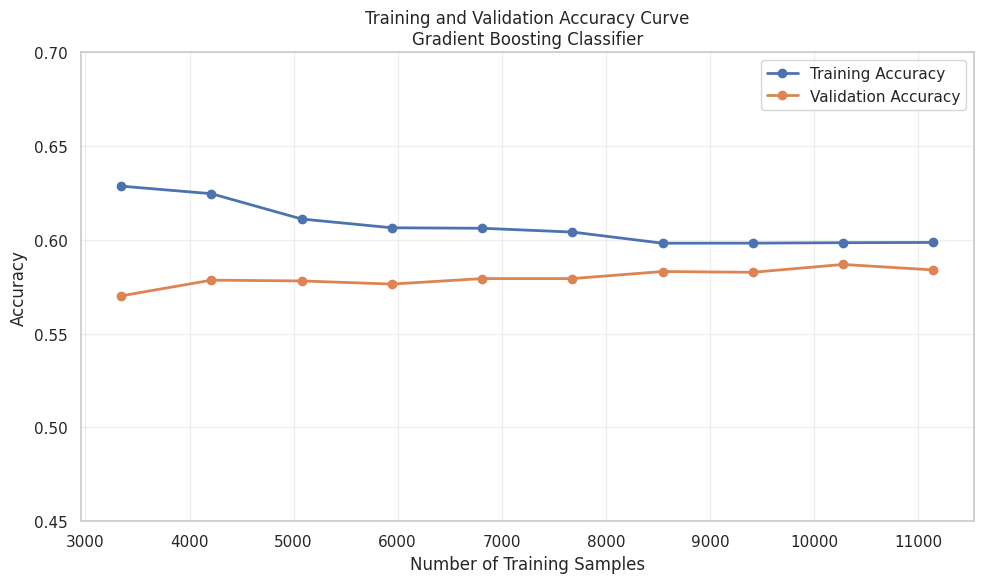

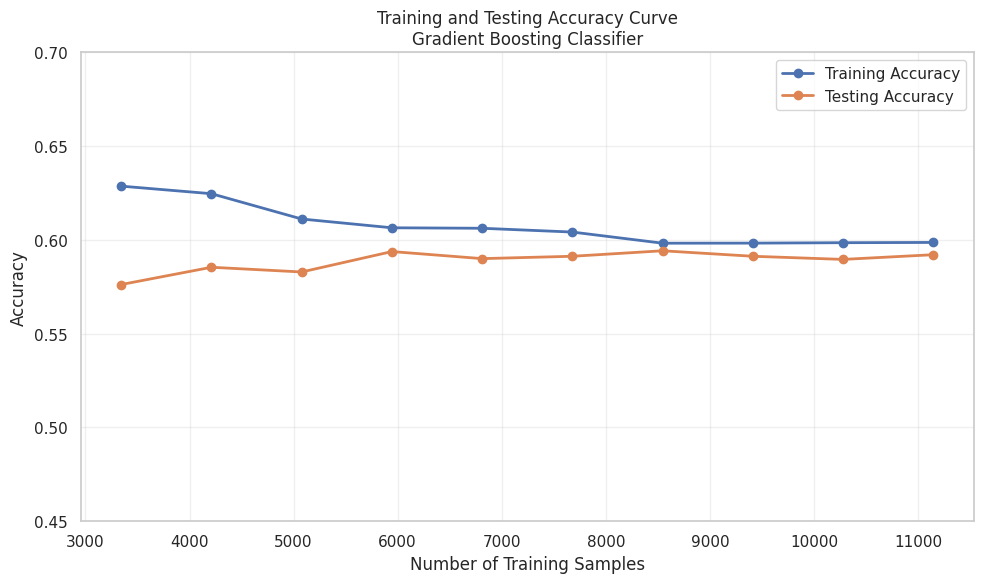

In [45]:
from sklearn.base import clone

# ---------------------------------------------------------
# Training / Validation / Testing Accuracy Learning Curve
# ---------------------------------------------------------

from sklearn.base import clone

# =========================================================
# TRAINING, VALIDATION AND TESTING ACCURACY ANALYSIS
# =========================================================

# Use progressively larger portions of the training dataset
training_fractions = np.linspace(
    0.30,
    1.00,
    10
)

curve_results = []


# ---------------------------------------------------------
# Calculate Training, Validation and Testing Accuracy
# ---------------------------------------------------------

for fraction in training_fractions:

    number_of_rows = int(
        len(X_train) * fraction
    )

    X_train_part = X_train.iloc[
        :number_of_rows
    ].copy()

    y_train_part = y_train.iloc[
        :number_of_rows
    ].copy()


    # Create a fresh copy of the final selected model
    curve_model = clone(
        trained_classifiers[
            best_match_model_name
        ]
    )


    # Train the model using the current training subset
    curve_model.fit(
        X_train_part,
        y_train_part
    )


    # -----------------------------------------------------
    # Training Accuracy
    # -----------------------------------------------------

    training_prediction = curve_model.predict(
        X_train_part
    )

    training_accuracy = accuracy_score(
        y_train_part,
        training_prediction
    )


    # -----------------------------------------------------
    # Validation Accuracy
    # -----------------------------------------------------

    validation_prediction = curve_model.predict(
        X_val
    )

    validation_accuracy = accuracy_score(
        y_val,
        validation_prediction
    )


    # -----------------------------------------------------
    # Testing Accuracy
    # -----------------------------------------------------

    testing_prediction = curve_model.predict(
        X_test
    )

    testing_accuracy = accuracy_score(
        y_test,
        testing_prediction
    )


    curve_results.append([
        number_of_rows,
        training_accuracy,
        validation_accuracy,
        testing_accuracy
    ])


# ---------------------------------------------------------
# Create Accuracy Results Table
# ---------------------------------------------------------

accuracy_curve_df = pd.DataFrame(
    curve_results,
    columns=[
        'Training Samples',
        'Training Accuracy',
        'Validation Accuracy',
        'Testing Accuracy'
    ]
)


print("=" * 65)
print("TRAINING, VALIDATION AND TESTING ACCURACY VALUES")
print("=" * 65)

display(
    accuracy_curve_df.round(4)
)


# =========================================================
# FIGURE 1: TRAINING VS VALIDATION ACCURACY
# =========================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    accuracy_curve_df['Training Samples'],
    accuracy_curve_df['Training Accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    accuracy_curve_df['Training Samples'],
    accuracy_curve_df['Validation Accuracy'],
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title(
    f'Training and Validation Accuracy Curve\n'
    f'{best_match_model_name}'
)

plt.xlabel(
    'Number of Training Samples'
)

plt.ylabel(
    'Accuracy'
)

# Zoom in to make genuine performance changes easier to see
plt.ylim(
    0.45,
    0.70
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# =========================================================
# FIGURE 2: TRAINING VS TESTING ACCURACY
# =========================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    accuracy_curve_df['Training Samples'],
    accuracy_curve_df['Training Accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    accuracy_curve_df['Training Samples'],
    accuracy_curve_df['Testing Accuracy'],
    marker='o',
    linewidth=2,
    label='Testing Accuracy'
)

plt.title(
    f'Training and Testing Accuracy Curve\n'
    f'{best_match_model_name}'
)

plt.xlabel(
    'Number of Training Samples'
)

plt.ylabel(
    'Accuracy'
)

# Same scale so both figures are directly comparable
plt.ylim(
    0.45,
    0.70
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

TRAINING, VALIDATION AND TESTING LOG-LOSS VALUES


,Training Samples,Training Loss,Validation Loss,Testing Loss
0,3344,0.8086,0.9410,0.9242
1,4211,0.8211,0.9346,0.9168
2,5078,0.8429,0.9307,0.9137
3,5945,0.8464,0.9268,0.9047
4,6812,0.8541,0.9246,0.9020
5,7679,0.8587,0.9254,0.8994
6,8546,0.8678,0.9218,0.8933
7,9413,0.8686,0.9198,0.8928
8,10280,0.8685,0.9162,0.8896
9,11148,0.8630,0.9179,0.8900


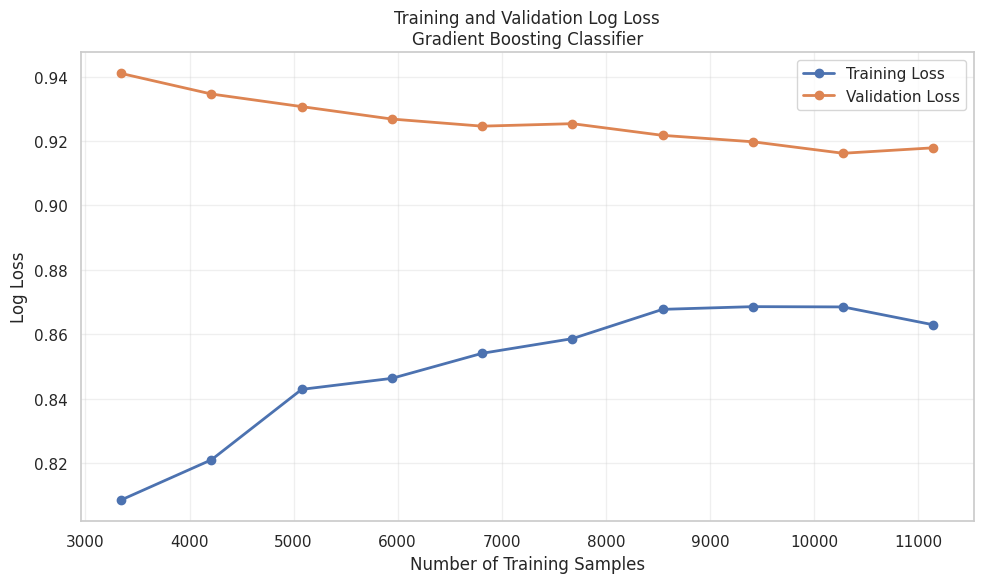

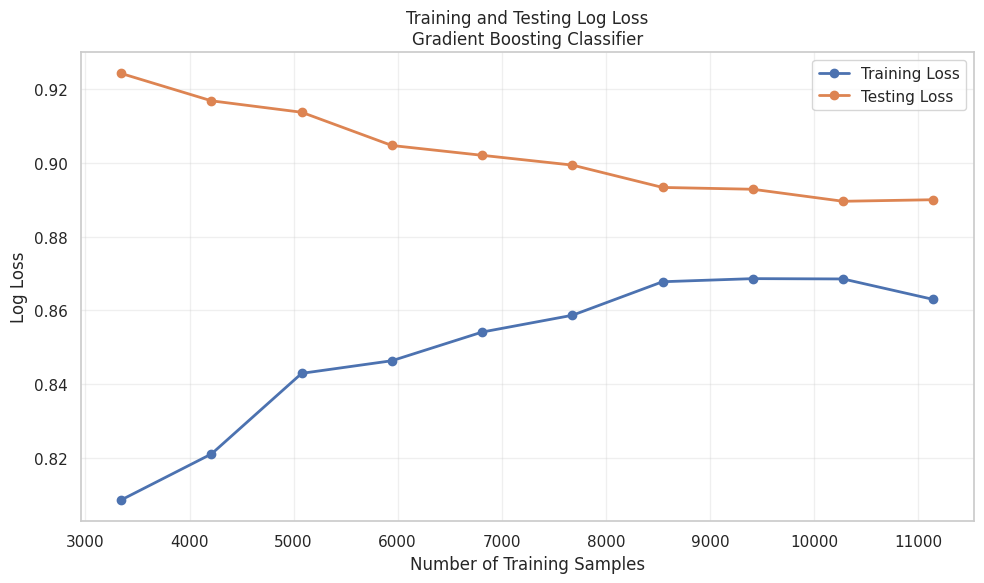

In [46]:
from sklearn.base import clone
from sklearn.metrics import log_loss

# =========================================================
# TRAINING, VALIDATION AND TESTING LOG-LOSS ANALYSIS
# =========================================================

# Use progressively larger portions of the training dataset
training_fractions_loss = np.linspace(
    0.30,
    1.00,
    10
)

loss_results = []


# ---------------------------------------------------------
# Calculate Training, Validation and Testing Log Loss
# ---------------------------------------------------------

for fraction in training_fractions_loss:

    number_of_rows = int(
        len(X_train) * fraction
    )

    X_train_part = X_train.iloc[
        :number_of_rows
    ].copy()

    y_train_part = y_train.iloc[
        :number_of_rows
    ].copy()


    # Create a fresh copy of the selected model
    loss_model = clone(
        trained_classifiers[
            best_match_model_name
        ]
    )


    # Train model on the current training subset
    loss_model.fit(
        X_train_part,
        y_train_part
    )


    # -----------------------------------------------------
    # Predicted Class Probabilities
    # -----------------------------------------------------

    train_probabilities = loss_model.predict_proba(
        X_train_part
    )

    validation_probabilities = loss_model.predict_proba(
        X_val
    )

    testing_probabilities = loss_model.predict_proba(
        X_test
    )


    # -----------------------------------------------------
    # Training Log Loss
    # -----------------------------------------------------

    training_loss = log_loss(
        y_train_part,
        train_probabilities,
        labels=loss_model.classes_
    )


    # -----------------------------------------------------
    # Validation Log Loss
    # -----------------------------------------------------

    validation_loss = log_loss(
        y_val,
        validation_probabilities,
        labels=loss_model.classes_
    )


    # -----------------------------------------------------
    # Testing Log Loss
    # -----------------------------------------------------

    testing_loss = log_loss(
        y_test,
        testing_probabilities,
        labels=loss_model.classes_
    )


    loss_results.append([
        number_of_rows,
        training_loss,
        validation_loss,
        testing_loss
    ])


# ---------------------------------------------------------
# Create Loss Results Table
# ---------------------------------------------------------

loss_curve_df = pd.DataFrame(
    loss_results,
    columns=[
        'Training Samples',
        'Training Loss',
        'Validation Loss',
        'Testing Loss'
    ]
)


print("=" * 65)
print("TRAINING, VALIDATION AND TESTING LOG-LOSS VALUES")
print("=" * 65)

display(
    loss_curve_df.round(4)
)


# =========================================================
# FIGURE 1: TRAINING VS VALIDATION LOSS
# =========================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    loss_curve_df['Training Samples'],
    loss_curve_df['Training Loss'],
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    loss_curve_df['Training Samples'],
    loss_curve_df['Validation Loss'],
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

plt.title(
    f'Training and Validation Log Loss\n'
    f'{best_match_model_name}'
)

plt.xlabel(
    'Number of Training Samples'
)

plt.ylabel(
    'Log Loss'
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# =========================================================
# FIGURE 2: TRAINING VS TESTING LOSS
# =========================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    loss_curve_df['Training Samples'],
    loss_curve_df['Training Loss'],
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    loss_curve_df['Training Samples'],
    loss_curve_df['Testing Loss'],
    marker='o',
    linewidth=2,
    label='Testing Loss'
)

plt.title(
    f'Training and Testing Log Loss\n'
    f'{best_match_model_name}'
)

plt.xlabel(
    'Number of Training Samples'
)

plt.ylabel(
    'Log Loss'
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

**7.11 Match Outcome Model Performance Comparison**

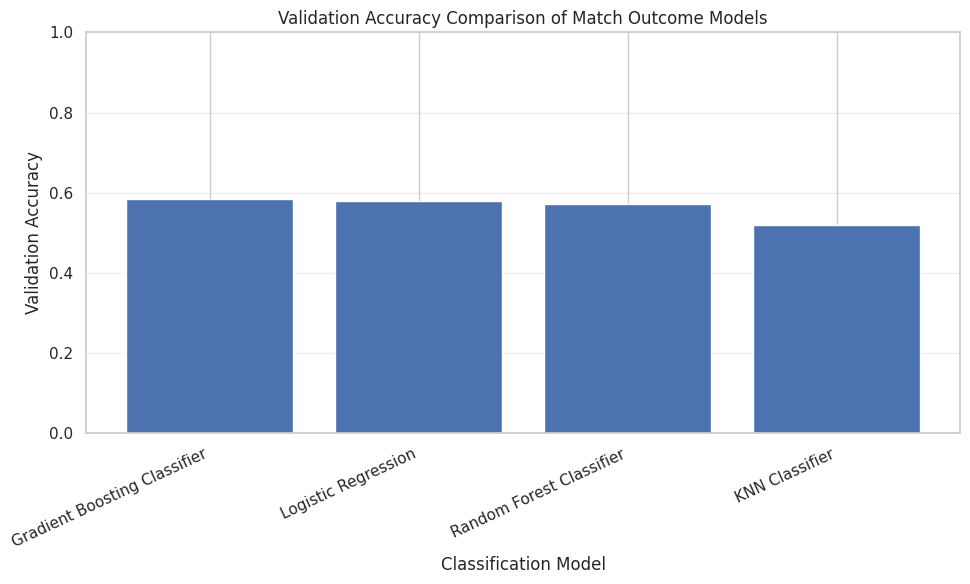

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    classification_results_df['Model'],
    classification_results_df['Validation Accuracy']
)

plt.ylabel('Validation Accuracy')

plt.xlabel('Classification Model')

plt.title(
    'Validation Accuracy Comparison of Match Outcome Models'
)

plt.ylim(0, 1)

plt.xticks(
    rotation=25,
    ha='right'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.show()

# 8. Final Prediction System

**8.1 Retrieve Latest Team Form**

In [48]:
def get_latest_team_form(team_name, n=5):
    """
    Calculates recent form from the last n international matches.
    Output: average points, goals scored, goals conceded.
    """
    
    home_matches = results[results['home_team_std'] == team_name][
        ['date', 'home_score', 'away_score', 'home_points']
    ].copy()
    
    home_matches = home_matches.rename(columns={
        'home_score': 'goals_for',
        'away_score': 'goals_against',
        'home_points': 'points'
    })
    
    away_matches = results[results['away_team_std'] == team_name][
        ['date', 'away_score', 'home_score', 'away_points']
    ].copy()
    
    away_matches = away_matches.rename(columns={
        'away_score': 'goals_for',
        'home_score': 'goals_against',
        'away_points': 'points'
    })
    
    all_matches = pd.concat([home_matches, away_matches], ignore_index=True)
    all_matches = all_matches.sort_values('date').tail(n)
    
    if all_matches.empty:
        return np.nan, np.nan, np.nan
    
    form_points = all_matches['points'].mean()
    goals_for = all_matches['goals_for'].mean()
    goals_against = all_matches['goals_against'].mean()
    
    return form_points, goals_for, goals_against


def get_latest_rank(team_name):
    team_rank = latest_ranking[latest_ranking['team_std'] == team_name].copy()
    
    if team_rank.empty:
        return np.nan
    
    team_rank = team_rank.sort_values('rank_date')
    return team_rank.iloc[-1]['rank']


def get_country_xi_strength(team_name):
    xi = recommend_best_xi(team_name, entity_type='country')
    
    if xi.empty:
        return np.nan
    
    return xi['ml_suitability_score'].mean()

**8.2 Integrated Match Prediction and XI Recommendation Function**

In [49]:
def predict_country_match(
    team_1,
    team_2,
    formation='4-3-3',
    opponent_formation=None,
    neutral=True,
    show_pitch=True,
    show_opponent_xi=False,
    show_evaluation=True
):
    """
    Final project system:

    1. Recommends an opponent-adjusted XI.
    2. Calculates XI strength.
    3. Uses FIFA ranking and recent form.
    4. Predicts match outcome.
    5. Evaluates the recommended XI.
    6. Optionally shows the lineup on a pitch.
    """

    if opponent_formation is None:
        opponent_formation = formation

    print("================================================")
    print(
        f"FINAL MATCH PREDICTION: "
        f"{team_1} vs {team_2}"
    )

    print(
        f"{team_1} Formation: "
        f"{formation}"
    )

    print(
        f"{team_2} Formation: "
        f"{opponent_formation}"
    )

    print("================================================")


    # Each team is selected specifically
    # for its named opponent.
    team_1_xi = recommend_best_xi(
        team_1,
        entity_type='country',
        formation=formation,
        opponent_name=team_2
    )

    team_2_xi = recommend_best_xi(
        team_2,
        entity_type='country',
        formation=opponent_formation,
        opponent_name=team_1
    )


    if team_1_xi.empty or team_2_xi.empty:

        print(
            "One team has no player data. "
            "Please check country spelling."
        )
    
        return None
    
    
    if len(team_1_xi) != 11 or len(team_2_xi) != 11:
    
        print("\nMATCH PREDICTION STOPPED")
    
        print(
            f"{team_1} selected players: "
            f"{len(team_1_xi)}/11"
        )
    
        print(
            f"{team_2} selected players: "
            f"{len(team_2_xi)}/11"
        )
    
        print(
            "A complete starting XI is required "
            "for both teams."
        )
    
        return None


    # Use ML suitability strength because
    # the match model was trained on that scale.
    team_1_strength = (
        team_1_xi[
            'ml_suitability_score'
        ].mean()
    )

    team_2_strength = (
        team_2_xi[
            'ml_suitability_score'
        ].mean()
    )


    # These scores show the tactical suitability
    # of each XI against its selected opponent.
    team_1_tactical_fit = (
        team_1_xi[
            'opponent_adjusted_score'
        ].mean()
    )

    team_2_tactical_fit = (
        team_2_xi[
            'opponent_adjusted_score'
        ].mean()
    )


    team_1_rank = get_latest_rank(
        team_1
    )

    team_2_rank = get_latest_rank(
        team_2
    )


    (
        team_1_form,
        team_1_goals_for,
        team_1_goals_against
    ) = get_latest_team_form(
        team_1
    )


    (
        team_2_form,
        team_2_goals_for,
        team_2_goals_against
    ) = get_latest_team_form(
        team_2
    )


    input_data = pd.DataFrame([{

        'home_xi_strength':
            team_1_strength,

        'away_xi_strength':
            team_2_strength,

        'xi_strength_diff':
            team_1_strength
            - team_2_strength,

        'home_rank':
            team_1_rank,

        'away_rank':
            team_2_rank,

        'rank_diff':
            team_2_rank
            - team_1_rank,

        'home_form_points_last5':
            team_1_form,

        'away_form_points_last5':
            team_2_form,

        'home_goals_for_last5':
            team_1_goals_for,

        'away_goals_for_last5':
            team_2_goals_for,

        'home_goals_against_last5':
            team_1_goals_against,

        'away_goals_against_last5':
            team_2_goals_against,

        'neutral_int':
            int(neutral)
    }])


    # Fill any unavailable final-input value
    # with the training-data median.
    for column in model_features:
    
        if input_data[column].isnull().any():
    
            input_data[column] = (
                input_data[column]
                .fillna(
                    train_medians[column]
                )
            )


    input_data = input_data[
        model_features
    ]


    predicted_result = (
        best_match_model.predict(
            input_data
        )[0]
    )


    probabilities = (
        best_match_model.predict_proba(
            input_data
        )[0]
    )


    class_labels = (
        best_match_model
        .named_steps[
            'model'
        ]
        .classes_
    )


    probability_table = pd.DataFrame({

        'Outcome':
            class_labels,

        'Probability (%)':
            probabilities * 100

    }).sort_values(

        'Probability (%)',
        ascending=False
    )


    print("\nTEAM STRENGTH SUMMARY")
    print("--------------------------------")

    print(
        f"{team_1} XI Strength: "
        f"{team_1_strength:.2f}"
    )

    print(
        f"{team_1} Tactical Fit vs "
        f"{team_2}: "
        f"{team_1_tactical_fit:.2f}"
    )

    print(
        f"{team_2} XI Strength: "
        f"{team_2_strength:.2f}"
    )

    print(
        f"{team_2} Tactical Fit vs "
        f"{team_1}: "
        f"{team_2_tactical_fit:.2f}"
    )

    print(
        f"{team_1} FIFA Rank: "
        f"{team_1_rank}"
    )

    print(
        f"{team_2} FIFA Rank: "
        f"{team_2_rank}"
    )

    print(
        f"{team_1} Recent Form Points: "
        f"{team_1_form:.2f}"
    )

    print(
        f"{team_2} Recent Form Points: "
        f"{team_2_form:.2f}"
    )


    print("\nPREDICTED RESULT")
    print("--------------------------------")
    print(predicted_result)


    print("\nPROBABILITY TABLE")
    print("--------------------------------")
    display(probability_table)


    print(
        f"\n{team_1} Opponent-Adjusted "
        f"Recommended XI ({formation})"
    )

    display(team_1_xi)


    if show_opponent_xi:

        print(
            f"\n{team_2} Opponent-Adjusted "
            f"Recommended XI "
            f"({opponent_formation})"
        )

        display(team_2_xi)


    evaluation = evaluate_recommended_xi(

        entity_name=team_1,

        formation=formation,

        opponent_name=team_2,

        entity_type='country',

        recommended_xi=team_1_xi,

        show_tables=show_evaluation
    )


    if show_pitch:

        plot_lineup(
            team_1_xi,
            formation=formation,
            team_name=team_1
        )


    return {

        'team_1':
            team_1,

        'team_2':
            team_2,

        'team_1_xi':
            team_1_xi,

        'team_2_xi':
            team_2_xi,

        'team_1_formation':
            formation,

        'team_2_formation':
            opponent_formation,

        'team_1_tactical_fit':
            team_1_tactical_fit,

        'team_2_tactical_fit':
            team_2_tactical_fit,

        'input_features':
            input_data,

        'probability_table':
            probability_table,

        'predicted_result':
            predicted_result,

        'evaluation':
            evaluation
    }

# 9. Football Field Visualisation

**9.1 Draw Football Pitch**

In [50]:
def draw_pitch(ax):
    """
    Draw a simple football pitch using matplotlib.
    """
    # Pitch background
    ax.set_facecolor('#228B22')  # green
    
    # Outer boundaries
    ax.plot([0, 0], [0, 100], color='white')
    ax.plot([0, 100], [0, 0], color='white')
    ax.plot([100, 100], [0, 100], color='white')
    ax.plot([0, 100], [100, 100], color='white')
    
    # Halfway line
    ax.plot([0, 100], [50, 50], color='white')
    
    # Centre circle
    centre_circle = plt.Circle((50, 50), 9.15, color='white', fill=False)
    ax.add_patch(centre_circle)
    
    # Centre spot
    ax.plot(50, 50, 'wo', markersize=2)
    
    # Bottom penalty box
    ax.plot([20, 20], [0, 16], color='white')
    ax.plot([80, 80], [0, 16], color='white')
    ax.plot([20, 80], [16, 16], color='white')
    
    # Top penalty box
    ax.plot([20, 20], [84, 100], color='white')
    ax.plot([80, 80], [84, 100], color='white')
    ax.plot([20, 80], [84, 84], color='white')
    
    # Bottom 6-yard box
    ax.plot([35, 35], [0, 6], color='white')
    ax.plot([65, 65], [0, 6], color='white')
    ax.plot([35, 65], [6, 6], color='white')
    
    # Top 6-yard box
    ax.plot([35, 35], [94, 100], color='white')
    ax.plot([65, 65], [94, 100], color='white')
    ax.plot([35, 65], [94, 94], color='white')
    
    # Bottom penalty spot
    ax.plot(50, 11, 'wo', markersize=2)
    
    # Top penalty spot
    ax.plot(50, 89, 'wo', markersize=2)
    
    # Remove axes
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Football Field", color='white', fontsize=14)

**9.2 Arrange Players by Position**

In [51]:
def sort_players_for_line(players_df, group_name):
    """
    Sort players inside each line so the lineup looks more natural.
    """
    if players_df.empty:
        return players_df
    
    # Position priorities for better visual order
    defender_order = {
        'LB': 1, 'LWB': 2, 'CB': 3, 'RB': 4, 'RWB': 5
    }
    
    midfielder_order = {
        'LM': 1, 'CM': 2, 'CDM': 3, 'CAM': 4, 'RM': 5
    }
    
    attacker_order = {
        'LW': 1, 'CF': 2, 'ST': 3, 'RW': 4
    }
    
    def get_sort_value(pos):
        pos = str(pos)
        primary = pos.split(',')[0].strip()
        
        if group_name == 'Defender':
            return defender_order.get(primary, 99)
        elif group_name == 'Midfielder':
            return midfielder_order.get(primary, 99)
        elif group_name == 'Attacker':
            return attacker_order.get(primary, 99)
        else:
            return 99
    
    temp_df = players_df.copy()
    temp_df['sort_order'] = temp_df['primary_position'].apply(get_sort_value)
    temp_df = temp_df.sort_values(by=['sort_order', 'ml_suitability_score'], ascending=[True, False])
    
    return temp_df.drop(columns=['sort_order'])

**9.3 Visualise Recommended Starting XI**

In [52]:
def plot_lineup(
    team_xi,
    formation='4-3-3',
    team_name='Team'
):
    """
    Plot the selected XI using the exact tactical
    slots created by the recommendation system.
    """

    if team_xi.empty:

        print(
            "No lineup data to plot."
        )

        return


    fig, ax = plt.subplots(
        figsize=(8, 12)
    )

    draw_pitch(
        ax
    )


    ax.set_title(
        f"{team_name} Recommended Best XI "
        f"({formation})",
        color='white',
        fontsize=16,
        pad=20
    )


    slot_spec = (
        _formation_slot_spec(
            formation
        )
    )


    # Y coordinate for each tactical line
    group_y = {
        'Goalkeeper': 10,
        'Defender': 30,
        'Midfielder': 55,
        'Attacker': 82
    }


    def get_x_positions(n):

        if n <= 0:
            return []

        if n == 1:
            return [50]

        return np.linspace(
            15,
            85,
            n
        )


    def plot_player_label(
        x,
        y,
        player
    ):

        name = (
            player[
                'short_name'
            ]
        )


        if (
            'selected_slot'
            in player.index
            and
            pd.notna(
                player[
                    'selected_slot'
                ]
            )
        ):

            position_label = (
                player[
                    'selected_slot'
                ]
            )

        else:

            position_label = (
                player[
                    'primary_position'
                ]
            )


        label = (
            f"{name}\n"
            f"({position_label})"
        )


        ax.text(
            x,
            y,
            label,

            color='black',

            ha='center',
            va='center',

            fontsize=8,

            fontweight='bold',

            bbox=dict(
                boxstyle=
                'round,pad=0.35',

                facecolor=
                'white',

                edgecolor=
                'black',

                linewidth=1,

                alpha=0.95
            ),

            zorder=5
        )


    # -----------------------------------------------------
    # Plot each tactical line
    # -----------------------------------------------------

    for group in [
        'Goalkeeper',
        'Defender',
        'Midfielder',
        'Attacker'
    ]:


        expected_slots = [

            slot

            for (
                slot,
                slot_group,
                _
            )

            in slot_spec

            if slot_group == group
        ]


        group_players = (
            team_xi[
                team_xi[
                    'position_group'
                ]
                == group
            ]
            .copy()
        )


        if group_players.empty:
            continue


        ordered_players = []


        # Use tactical-slot order
        # instead of simple rating order
        if (
            'selected_slot'
            in group_players.columns
        ):

            for slot in expected_slots:

                match = (
                    group_players[
                        group_players[
                            'selected_slot'
                        ]
                        == slot
                    ]
                )

                if not match.empty:

                    ordered_players.append(
                        match.head(1)
                    )


            if ordered_players:

                group_players = (
                    pd.concat(
                        ordered_players,
                        ignore_index=False
                    )
                )


        else:

            group_players = (
                sort_players_for_line(
                    group_players,
                    group
                )
            )


        x_positions = (
            get_x_positions(
                len(
                    group_players
                )
            )
        )


        y = group_y[
            group
        ]


        for (
            x,
            (_, player)
        ) in zip(
            x_positions,
            group_players.iterrows()
        ):

            plot_player_label(
                x,
                y,
                player
            )


    plt.tight_layout()

    plt.show()

# 10. Final System Input and Output

**10.1 Final International Match Test**

10.1.1 Run Final Argentina vs France Prediction

FINAL MATCH PREDICTION: Argentina vs Brazil
Argentina Formation: 4-3-3
Brazil Formation: 4-3-3
Argentina Best XI vs Brazil using 4-3-3
Brazil Best XI vs Argentina using 4-3-3

TEAM STRENGTH SUMMARY
--------------------------------
Argentina XI Strength: 82.70
Argentina Tactical Fit vs Brazil: 82.52
Brazil XI Strength: 83.35
Brazil Tactical Fit vs Argentina: 83.65
Argentina FIFA Rank: 1
Brazil FIFA Rank: 5
Argentina Recent Form Points: 3.00
Brazil Recent Form Points: 2.00

PREDICTED RESULT
--------------------------------
Draw

PROBABILITY TABLE
--------------------------------


,Outcome,Probability (%)
1,Draw,39.663805
0,Away Win,31.375585
2,Home Win,28.960610



Argentina Opponent-Adjusted Recommended XI (4-3-3)


,player_id,short_name,long_name,country_std,club_name,league_name,player_positions,primary_position,position_group,selected_slot,slot_match,overall,ml_suitability_score,opponent_adjusted_score
80,202811,E. Martínez,Damián Emiliano Martínez,Argentina,Aston Villa,Premier League,GK,GK,Goalkeeper,GK,Compatible position,85,83.4850,83.594199
90,224334,M. Acuña,Marcos Javier Acuña,Argentina,Sevilla,La Liga,"LB, LM",LB,Defender,LB,Compatible position,85,80.1620,80.011000
98,239301,L. Martínez,Lisandro Martínez,Argentina,Manchester United,Premier League,CB,CB,Defender,LCB,Compatible position,84,82.5275,82.333809
208,232488,C. Romero,Cristian Gabriel Romero,Argentina,Tottenham Hotspur,Premier League,CB,CB,Defender,RCB,Compatible position,82,81.4430,81.035076
378,237221,J. Foyth,Juan Marcos Foyth,Argentina,Villarreal,La Liga,"RB, CB, CDM",RB,Defender,RB,Compatible position,80,78.8570,78.660815
137,212616,R. De Paul,Rodrigo Javier De Paul,Argentina,Atlético Madrid,La Liga,CM,CM,Midfielder,LCM,Compatible position,84,82.5290,82.576915
144,247090,E. Fernández,Enzo Jeremías Fernández,Argentina,Chelsea,Premier League,"CM, CDM",CM,Midfielder,CM,Compatible position,83,82.0360,81.381664
228,239837,A. Mac Allister,Alexis Mac Allister,Argentina,Liverpool,Premier League,"CM, CAM, CDM",CM,Midfielder,RCM,Compatible position,82,81.4085,80.286582
3,158023,L. Messi,Lionel Andrés Messi Cuccittini,Argentina,Inter Miami,Major League Soccer,"CF, CAM",CF,Attacker,LW,Compatible position,90,87.1245,87.509091
28,231478,L. Martínez,Lautaro Javier Martínez,Argentina,Inter,Serie A,ST,ST,Attacker,ST,Compatible position,87,86.7630,86.405155



EVALUATION: Argentina (4-3-3)
--------------------------------


,Position Group,Required,Selected,Correct
0,Goalkeeper,1,1,True
1,Defender,4,4,True
2,Midfielder,3,3,True
3,Attacker,3,3,True


,Metric,Result
0,Selected players,11
1,Position accuracy (%),100.0
2,Formation complete,True
3,Duplicate players,0
4,Recommended XI average overall,84.0
5,Top-rated XI average overall,84.64
6,Recommended XI average ML suitability,82.7
7,Top-rated XI average ML suitability,82.11
8,Players common to both XIs,8/11



Highest-rated XI used for comparison


,player_id,short_name,long_name,primary_position,position_group,overall,ml_suitability_score
80,202811,E. Martínez,Damián Emiliano Martínez,GK,Goalkeeper,85,83.4850
90,224334,M. Acuña,Marcos Javier Acuña,LB,Defender,85,80.1620
98,239301,L. Martínez,Lisandro Martínez,CB,Defender,84,82.5275
208,232488,C. Romero,Cristian Gabriel Romero,CB,Defender,82,81.4430
210,233084,N. Molina,Nahuel Molina Lucero,RB,Defender,82,76.8595
137,212616,R. De Paul,Rodrigo Javier De Paul,CM,Midfielder,84,82.5290
159,225659,G. Rodríguez,Guido Rodríguez,CDM,Midfielder,83,77.6825
144,247090,E. Fernández,Enzo Jeremías Fernández,CM,Midfielder,83,82.0360
3,158023,L. Messi,Lionel Andrés Messi Cuccittini,CF,Attacker,90,87.1245
28,231478,L. Martínez,Lautaro Javier Martínez,ST,Attacker,87,86.7630


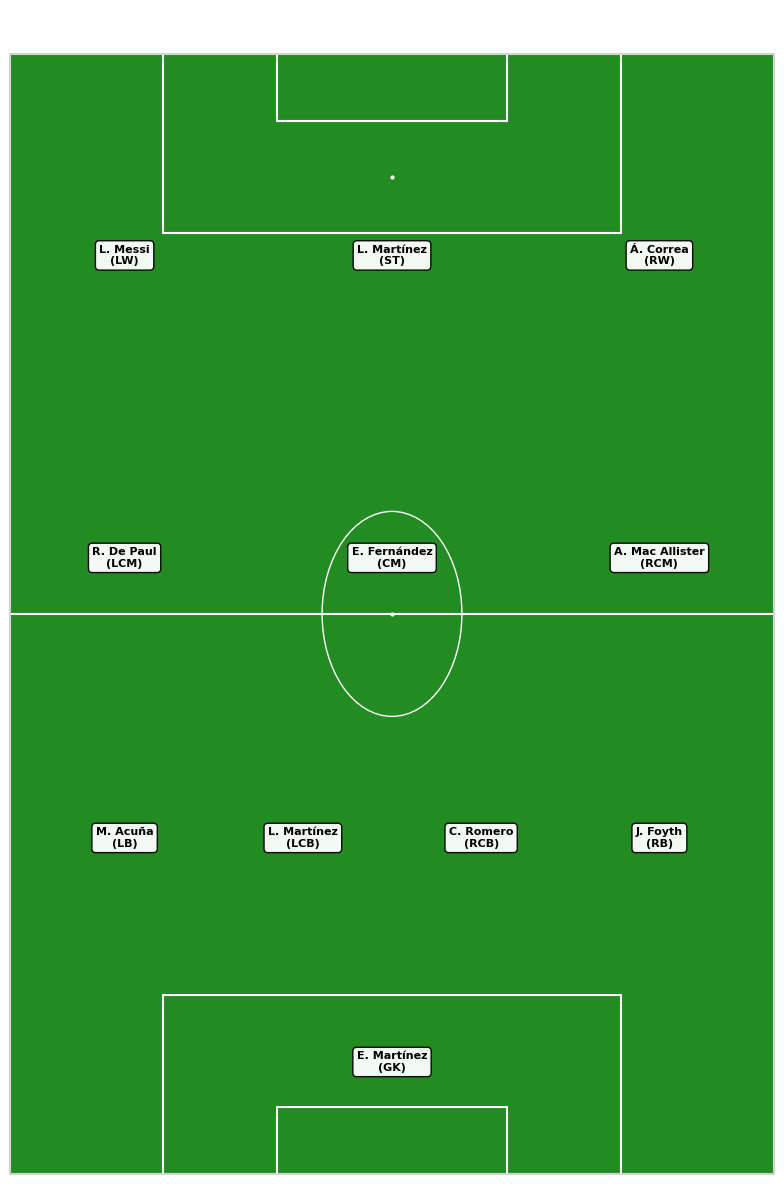

In [53]:
final_result = predict_country_match(

    team_1='Argentina',

    team_2='Brazil',

    formation='4-3-3',

    opponent_formation='4-3-3',

    neutral=True,

    show_pitch=True,

    show_opponent_xi=False,

    show_evaluation=True
)

**10.2 Predicted Match Outcome Probability**

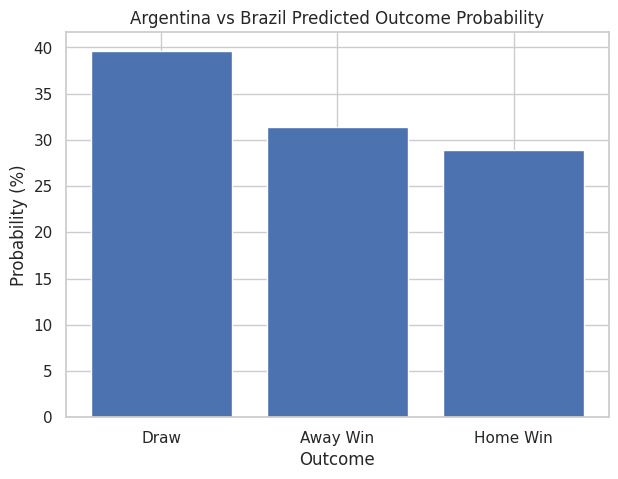

In [54]:
if final_result is not None:

    prob_table = final_result[
        'probability_table'
    ]

    plt.figure(figsize=(7, 5))

    plt.bar(
        prob_table['Outcome'],
        prob_table['Probability (%)']
    )

    plt.title(
        f"{final_result['team_1']} vs "
        f"{final_result['team_2']} "
        "Predicted Outcome Probability"
    )

    plt.xlabel('Outcome')
    plt.ylabel('Probability (%)')
    plt.show()

else:

    print(
        "Probability chart was not created because "
        "a complete starting XI was unavailable."
    )

**10.3 Demonstrate Opponent-Dependent Player Selection**

In [55]:
xi_vs_france = recommend_best_xi(
    'Argentina',
    entity_type='country',
    formation='4-3-3',
    opponent_name='France',
    verbose=False
)


xi_vs_brazil = recommend_best_xi(
    'Argentina',
    entity_type='country',
    formation='4-3-3',
    opponent_name='Brazil',
    verbose=False
)


opponent_test = xi_vs_france[
    [
        'player_id',
        'short_name',
        'long_name',
        'opponent_adjusted_score'
    ]
].merge(
    xi_vs_brazil[
        [
            'player_id',
            'opponent_adjusted_score'
        ]
    ],
    on='player_id',
    how='outer',
    suffixes=(
        '_vs_France',
        '_vs_Brazil'
    )
)


opponent_test

,player_id,short_name,long_name,opponent_adjusted_score_vs_France,opponent_adjusted_score_vs_Brazil
0,158023,L. Messi,Lionel Andrés Messi Cuccittini,87.504766,87.509091
1,202811,E. Martínez,Damián Emiliano Martínez,83.591870,83.594199
2,212616,R. De Paul,Rodrigo Javier De Paul,82.563713,82.576915
3,214997,Á. Correa,Ángel Martín Correa,83.936563,83.937556
4,224334,M. Acuña,Marcos Javier Acuña,80.029152,80.011000
5,231478,L. Martínez,Lautaro Javier Martínez,86.404099,86.405155
6,232488,C. Romero,Cristian Gabriel Romero,81.067361,81.035076
7,237221,J. Foyth,Juan Marcos Foyth,78.685085,78.660815
8,239301,L. Martínez,Lisandro Martínez,82.363766,82.333809
9,239837,A. Mac Allister,Alexis Mac Allister,80.271557,80.286582


# Club or league comparison

In [56]:
compare_two_teams('Real Madrid', 'FC Barcelona', entity_type='club', formation ='3-4-3')

Real Madrid Best XI vs FC Barcelona using 3-4-3
FC Barcelona Best XI vs Real Madrid using 3-4-3
Formation: 3-4-3
Real Madrid XI Strength: 83.04
Real Madrid Tactical Fit vs FC Barcelona: 83.12
FC Barcelona XI Strength: 83.85
FC Barcelona Tactical Fit vs Real Madrid: 83.60
FC Barcelona has the stronger selected XI based on player attributes.


(      player_id     short_name                                long_name  \
 6        192119    T. Courtois            Thibaut Nicolas Marc Courtois   
 43       240130   Éder Militão                     Éder Gabriel Militão   
 81       205452     A. Rüdiger                          Antonio Rüdiger   
 78       197445       D. Alaba                   David Olatukunbo Alaba   
 33       177003      L. Modrić                              Luka Modrić   
 17       239053    F. Valverde       Federico Santiago Valverde Dipetta   
 39       252371  J. Bellingham           Jude Victor William Bellingham   
 50       182521       T. Kroos                               Toni Kroos   
 8        238794       Vini Jr.  Vinícius José Paixão de Oliveira Júnior   
 61       243812        Rodrygo                    Rodrygo Silva de Goes   
 7230     265194     Iker Bravo                     Iker Bravo Solanilla   
 
      country_std    club_name league_name player_positions primary_position  \
 6    

In [57]:
compare_two_teams('Premier League', 'La Liga', entity_type='league')

Premier League Best XI vs La Liga using 4-3-3
La Liga Best XI vs Premier League using 4-3-3
Formation: 4-3-3
Premier League XI Strength: 86.50
Premier League Tactical Fit vs La Liga: 85.94
La Liga XI Strength: 85.53
La Liga Tactical Fit vs Premier League: 85.43
Premier League has the stronger selected XI based on player attributes.


(     player_id       short_name                                long_name  \
 9       212831          Alisson                    Alisson Ramsés Becker   
 201     251517      J. Gvardiol                           Joško Gvardiol   
 15      203376      V. van Dijk                          Virgil van Dijk   
 11      239818       Rúben Dias         Rúben dos Santos Gato Alves Dias   
 70      203574        J. Stones                              John Stones   
 2       192985     K. De Bruyne                          Kevin De Bruyne   
 24      218667   Bernardo Silva  Bernardo Mota Veiga de Carvalho e Silva   
 23      212198  Bruno Fernandes            Bruno Miguel Borges Fernandes   
 34      200104           H. Son                                  손흥민 孙兴慜   
 1       239085       E. Haaland                     Erling Braut Haaland   
 16      209331         M. Salah                      Mohamed Salah Ghaly   
 
      country_std          club_name     league_name player_positions  \
 